In [4]:
# ── توصيل Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

# ── تثبيت المكتبات ──
!pip install opencv-python-headless matplotlib numpy tensorflow pillow \
  tqdm scikit-learn seaborn openai-whisper -q

# ── إخفاء التحذيرات  ─
import warnings
warnings.filterwarnings('ignore')

# ── توصيل Kaggle ──
import os
from google.colab import files

print("⬆️ ارفع ملف kaggle.json من حسابك في Kaggle")
files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle متصل بنجاح!")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
⬆️ ارفع ملف kaggle.json من حسابك في Kaggle


Saving kaggle.json to kaggle.json
✅ Kaggle متصل بنجاح!


In [14]:
# ================================================================
#  Download + Cache in Google Drive
# ================================================================
import os, shutil, json

DRIVE_PATH = '/content/drive/MyDrive/wlasl_data'

def load_from_drive():
    """نسخ الداتا من Drive إذا موجودة"""
    if os.path.exists(os.path.join(DRIVE_PATH, 'videos')):
        print("📂 Loading from Google Drive cache...")
        if os.path.exists('/content/videos'):
            shutil.rmtree('/content/videos')
        shutil.copytree(os.path.join(DRIVE_PATH, 'videos'), '/content/videos')
        for f in os.listdir(DRIVE_PATH):
            if f.endswith(('.json', '.txt')):
                shutil.copy2(os.path.join(DRIVE_PATH, f), f'/content/{f}')
        print("✅ Loaded from Drive!")
        return True
    return False

def save_to_drive():
    """حفظ الداتا في Drive عشان المرة الجاية"""
    print("💾 Saving to Google Drive...")
    os.makedirs(DRIVE_PATH, exist_ok=True)
    if os.path.exists('/content/videos'):
        if os.path.exists(os.path.join(DRIVE_PATH, 'videos')):
            shutil.rmtree(os.path.join(DRIVE_PATH, 'videos'))
        shutil.copytree('/content/videos', os.path.join(DRIVE_PATH, 'videos'))
    for f in os.listdir('/content'):
        if f.endswith(('.json', '.txt')):
            shutil.copy2(f'/content/{f}', os.path.join(DRIVE_PATH, f))
    print("✅ Saved to Drive! Next run will be faster.")

# ── توصيل Drive ──
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

# ── محاولة تحميل من Drive أولاً ──
if not load_from_drive():
    # تحميل من Kaggle
    print("⬇️ Downloading from Kaggle...")
    !kaggle datasets download -d gazquez/wlasl-processed -p /content/

    zip_path = '/content/wlasl-processed.zip'
    if not os.path.exists(zip_path):
        raise FileNotFoundError("❌ Download failed!")

    print("📂 Extracting...")
    !unzip -q /content/wlasl-processed.zip -d /content/
    !rm /content/wlasl-processed.zip

    # تنظيم
    wlasl_root = None
    for root, dirs, files in os.walk('/content'):
        if len(files) > 5 or 'videos' in dirs:
            wlasl_root = root
            break

    video_src = os.path.join(wlasl_root, 'videos')
    if os.path.exists(video_src) and video_src != '/content/videos':
        if os.path.exists('/content/videos'):
            shutil.rmtree('/content/videos')
        shutil.move(video_src, '/content/videos')

    for f in os.listdir(wlasl_root):
        if f.endswith(('.json', '.txt')):
            shutil.move(os.path.join(wlasl_root, f), f'/content/{f}')

    if wlasl_root != '/content':
        shutil.rmtree(wlasl_root)

    # حفظ في Drive
    save_to_drive()

# ── التحقق النهائي ──
print("\n" + "=" * 60)
print("  Final Verification")
print("=" * 60)
print(f"  Videos: {len(os.listdir('/content/videos'))}")

for name in ['WLASL_v0.3.json']:
    path = f'/content/{name}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {name} ({size:.0f} KB)")
    else:
        print(f"  ❌ {name} NOT FOUND!")

if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json', 'r') as f:
        data = json.load(f)
    print(f"\n  WLASL words: {len(data)}")
    print(f"  First word: {data[0]['gloss']}")
    print(f"\n  Dataset READY! ✅")

📂 Loading from Google Drive cache...
✅ Loaded from Drive!

  Final Verification
  Videos: 21083
  ✅ WLASL_v0.3.json (6777 KB)

  WLASL words: 2000
  First word: book

  Dataset READY! ✅


In [7]:
import os, json

# ✅ المسار الصح
VIDEO_PATH = '/content/videos'
JSON_PATH = '/content/WLASL_v0.3.json'

# شوف الفيديوهات
video_files = sorted(os.listdir(VIDEO_PATH))
print(f"🎬 Total videos: {len(video_files)}")
print(f"   First 15: {video_files[:15]}")
print(f"   Last 5: {video_files[-5:]}")

# شوف الـ JSON
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"\n📋 WLASL words: {len(data)}")
print(f"   First word: {data[0]['gloss']}")
print(f"   Second word: {data[1]['gloss']}")

# شوف عدد الفيديوهات لكل كلمة (أول 10 كلمات)
print("\n📊 Videos per word (first 10):")
for i, entry in enumerate(data[:10]):
    gloss = entry['gloss']
    instances = entry.get('instances', [])
    video_ids = [inst.get('video_id', '?') for inst in instances]
    print(f"   {gloss}: {len(instances)} videos → IDs: {video_ids[:5]}")

🎬 Total videos: 21083
   First 15: ['00295.mp4', '00333.mp4', '00335.mp4', '00336.mp4', '00337.mp4', '00338.mp4', '00339.mp4', '00340.mp4', '00341.mp4', '00374.mp4', '00376.mp4', '00377.mp4', '00378.mp4', '00381.mp4', '00382.mp4']
   Last 5: ['70375.mp4', '70376.mp4', '70377.mp4', '70378.mp4', '70379.mp4']

📋 WLASL words: 2000
   First word: book
   Second word: drink

📊 Videos per word (first 10):
   book: 40 videos → IDs: ['69241', '65225', '68011', '68208', '68012']
   drink: 35 videos → IDs: ['69302', '65539', '70173', '68538', '68042']
   computer: 30 videos → IDs: ['12306', '68028', '69054', '12328', '12329']
   before: 26 videos → IDs: ['05724', '70348', '68007', '05744', '05746']
   chair: 26 videos → IDs: ['09847', '70230', '68580', '70263', '68019']
   go: 26 videos → IDs: ['24857', '69345', '68292', '24955', '24956']
   clothes: 25 videos → IDs: ['11305', '68870', '68024', '11327', '11328']
   who: 25 videos → IDs: ['63219', '69534', '68890', '68183', '63239']
   candy: 24 v

In [8]:
import os, json, shutil

VIDEO_PATH = '/content/videos'
JSON_PATH = '/content/WLASL_v0.3.json'
ORGANIZED_PATH = '/content/WLASL_organized'

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

os.makedirs(ORGANIZED_PATH, exist_ok=True)

# إنشاء مجلد لكل كلمة ونسخ الفيديوهات
for entry in data:
    gloss = entry['gloss']
    word_dir = os.path.join(ORGANIZED_PATH, gloss)
    os.makedirs(word_dir, exist_ok=True)

    for inst in entry.get('instances', []):
        video_id = inst.get('video_id', '')
        src = os.path.join(VIDEO_PATH, f'{video_id}.mp4')
        dst = os.path.join(word_dir, f'{video_id}.mp4')

        if os.path.exists(src):
            shutil.copy2(src, dst)

# تحقق
total_words = len(os.listdir(ORGANIZED_PATH))
print(f"✅ Organized {total_words} word folders in {ORGANIZED_PATH}")

✅ Organized 2000 word folders in /content/WLASL_organized


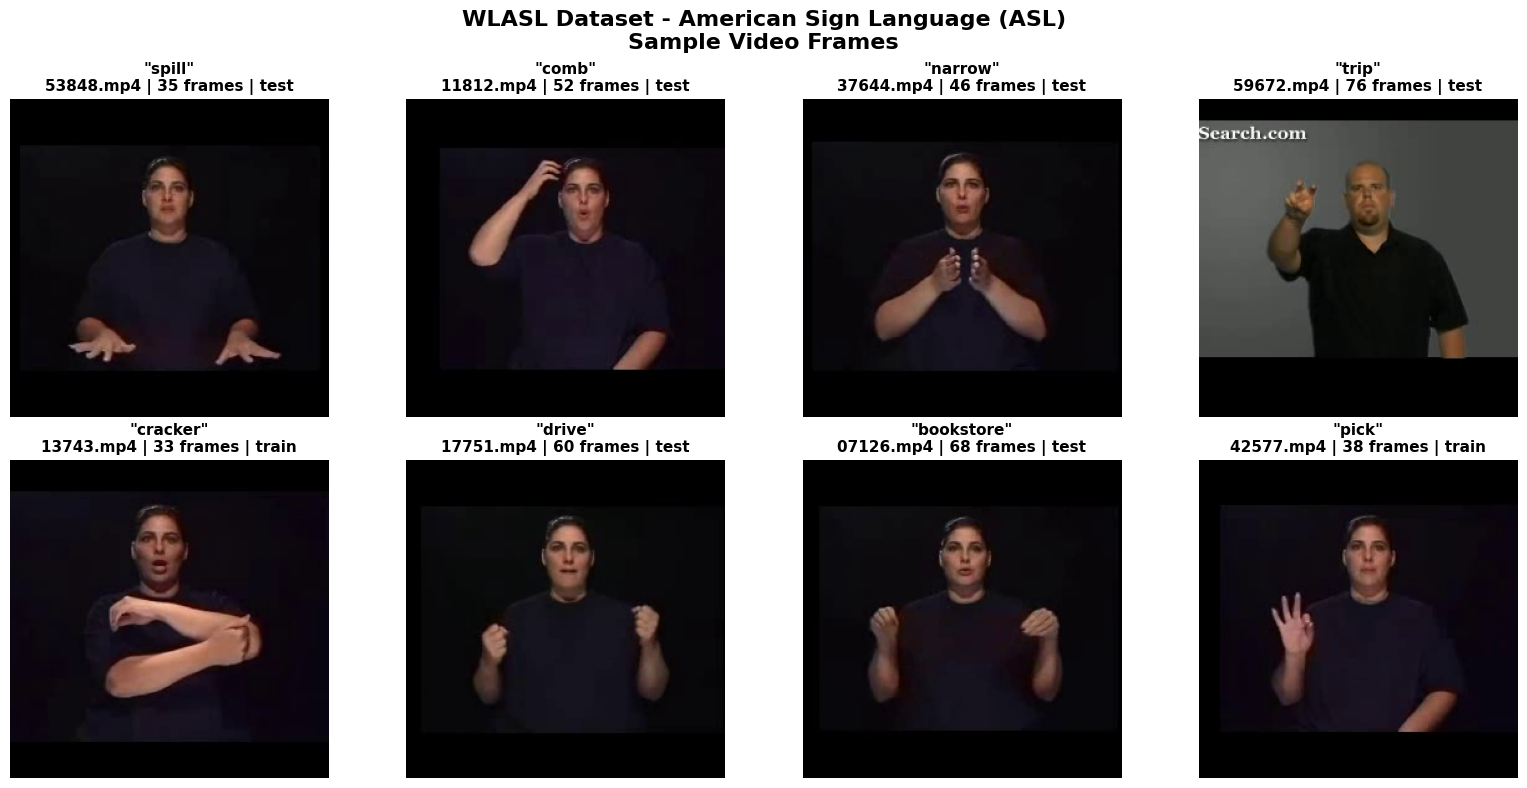

🎬 Total videos: 21083
📋 Total words: 2000
🖼️ Sample saved to: /content/wlasl_samples.png


In [9]:
# ================================================================
#  VISUALIZE: Sample WLASL Videos (extract frames from MP4)
# ================================================================
import cv2, matplotlib.pyplot as plt, json, random, os

random.seed(42)

VIDEO_DIR = '/content/videos'
JSON_PATH = '/content/WLASL_v0.3.json'

# ── قراءة JSON ──
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# ── بناء lookup: video_id → (gloss, split) ──
video_info = {}
for entry in data:
    gloss = entry['gloss']
    for inst in entry['instances']:
        video_info[str(inst['video_id'])] = (gloss, inst['split'])

# ── اختيار 8 كلمات عشوائية ──
all_words = list({entry['gloss'] for entry in data})
sample_words = random.sample(all_words, min(8, len(all_words)))

# ── لكل كلمة، لقّي أول فيديو واسبب إطار واحد ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('WLASL Dataset - American Sign Language (ASL)\nSample Video Frames',
             fontsize=16, fontweight='bold')

for ax, word in zip(axes.flatten(), sample_words):
    # لقّي فيديو لهالكلمة
    matching_videos = []
    for entry in data:
        if entry['gloss'] == word:
            for inst in entry['instances']:
                vid = str(inst['video_id'])
                mp4_path = os.path.join(VIDEO_DIR, f'{vid}.mp4')
                if os.path.exists(mp4_path):
                    matching_videos.append((vid, inst['split'], mp4_path))
            break

    if matching_videos:
        vid_id, split, mp4_path = matching_videos[0]
        cap = cv2.VideoCapture(mp4_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # خد الإطار من النص
        mid_frame = total_frames // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
        ret, frame = cap.read()
        cap.release()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(frame)
            ax.set_title(f'"{word}"\n{vid_id}.mp4 | {total_frames} frames | {split}',
                         fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'"{word}"\nNo video found', fontsize=11)

    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/wlasl_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🎬 Total videos: {len(os.listdir(VIDEO_DIR))}")
print(f"📋 Total words: {len(all_words)}")
print(f"🖼️ Sample saved to: /content/wlasl_samples.png")

In [10]:
# ================================================================
#  DATA LOADING: Load WLASL videos with train/val/test split
# ================================================================
import cv2, numpy as np, json, os, random
from tqdm import tqdm

# ── الإعدادات ──
NUM_WORDS = 100
FRAME_SIZE = (128, 128)
FRAMES_PER_VIDEO = 5       # عدد الإطارات من كل فيديو
RANDOM_SEED = 42
VIDEO_DIR = '/content/videos'
JSON_PATH = '/content/WLASL_v0.3.json'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── قراءة JSON ──
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# ── اختيار أفضل 100 كلمة (أكثر فيديوهات) ──
word_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
word_counts.sort(key=lambda x: x[1], reverse=True)
selected_words = [w for w, c in word_counts[:NUM_WORDS]]

label_map = {str(i): w for i, w in enumerate(selected_words)}
reverse_map = {w: i for i, w in enumerate(selected_words)}

print(f"Top 10 words: {selected_words[:10]}")
print(f"Videos per word range: {word_counts[0][1]} - {word_counts[NUM_WORDS-1][1]}")

# ── تحميل الإطارات من الفيديوهات ──
train_frames, val_frames, test_frames = [], [], []
train_labels, val_labels, test_labels = [], [], []

print(f"\nLoading {NUM_WORDS} words from MP4 videos...")

for entry in tqdm(data):
    gloss = entry['gloss']
    if gloss not in reverse_map:
        continue

    label_idx = reverse_map[gloss]

    for inst in entry['instances']:
        vid_id = str(inst['video_id'])
        split = inst.get('split', 'train')
        mp4_path = os.path.join(VIDEO_DIR, f'{vid_id}.mp4')

        if not os.path.exists(mp4_path):
            continue

        # ── استخراج إطارات من الفيديو ──
        cap = cv2.VideoCapture(mp4_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames < FRAMES_PER_VIDEO:
            cap.release()
            continue

        # اختيار إطارات متساوية المسافة
        frame_indices = np.linspace(
            0, total_frames - 1, FRAMES_PER_VIDEO, dtype=int
        )

        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, FRAME_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = frame.astype(np.float32) / 255.0

                if split == 'train':
                    train_frames.append(frame)
                    train_labels.append(label_idx)
                elif split == 'val':
                    val_frames.append(frame)
                    val_labels.append(label_idx)
                else:  # test
                    test_frames.append(frame)
                    test_labels.append(label_idx)

        cap.release()

# ── تحويل لـ numpy ──
X_train = np.array(train_frames, dtype=np.float32)
X_val   = np.array(val_frames,   dtype=np.float32)
X_test  = np.array(test_frames,  dtype=np.float32)
y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

# ── حفظ كل شي ──
np.save('/content/X_train.npy', X_train)
np.save('/content/X_val.npy', X_val)
np.save('/content/X_test.npy', X_test)
np.save('/content/y_train.npy', y_train)
np.save('/content/y_val.npy', y_val)
np.save('/content/y_test.npy', y_test)
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

# ── إحصائيات ──
total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\n{'=' * 50}")
print(f"  Data Split Summary")
print(f"{'=' * 50}")
print(f"  Total:   {total:>5} frames")
print(f"  Train:   {X_train.shape[0]:>5} frames ({X_train.shape[0]/total*100:.1f}%)")
print(f"  Val:     {X_val.shape[0]:>5} frames ({X_val.shape[0]/total*100:.1f}%)")
print(f"  Test:    {X_test.shape[0]:>5} frames ({X_test.shape[0]/total*100:.1f}%)")
print(f"  Classes: {NUM_WORDS}")
print(f"  Shape:   {X_train.shape[1:]}")
print(f"\n  📁 Saved: X_train, X_val, X_test, y_train, y_val, y_test, wlasl_labels.json")

Top 10 words: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']
Videos per word range: 40 - 18

Loading 100 words from MP4 videos...


100%|██████████| 2000/2000 [00:39<00:00, 50.54it/s]



  Data Split Summary
  Total:   10190 frames
  Train:    7210 frames (70.8%)
  Val:      1690 frames (16.6%)
  Test:     1290 frames (12.7%)
  Classes: 100
  Shape:   (128, 128, 3)

  📁 Saved: X_train, X_val, X_test, y_train, y_val, y_test, wlasl_labels.json


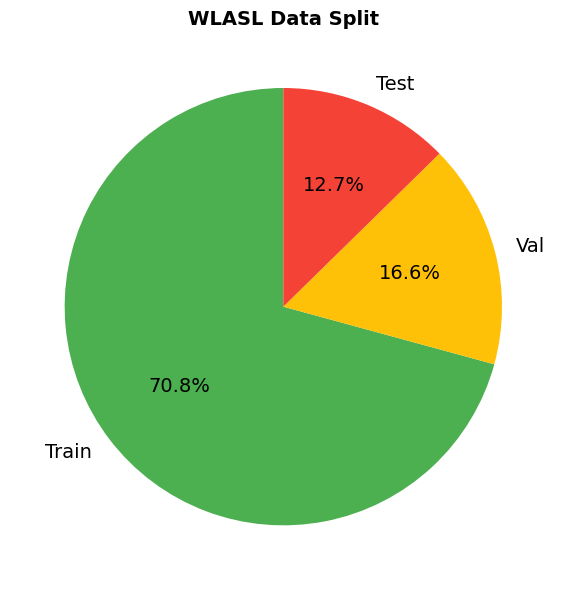

Train: 7210 | Val: 1690 | Test: 1290


In [11]:
# ================================================================
#  VISUALIZE: Data Split Pie Chart
# ================================================================
import numpy as np, matplotlib.pyplot as plt

X_train = np.load('/content/X_train.npy')
X_val = np.load('/content/X_val.npy')
X_test = np.load('/content/X_test.npy')

sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%',
        colors=['#4CAF50', '#FFC107', '#F44336'], startangle=90,
        textprops={'fontsize': 14})
plt.title('WLASL Data Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/wlasl_split.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train: {sizes[0]} | Val: {sizes[1]} | Test: {sizes[2]}")

In [12]:
# ================================================================
#  FRAME EXTRACTION (FIXED): Extract frames with safe bbox
# ================================================================
import cv2, numpy as np, json, os, random
from tqdm import tqdm
from sklearn.model_selection import train_test_split

NUM_WORDS = 50
FRAMES_PER_VIDEO = 10
FRAME_SIZE = (128, 128)
MAX_VIDEOS_PER_WORD = 15
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Extracting frames for {NUM_WORDS} words...")

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

video_dir = '/content/videos'

# بناء خريطة
word_to_videos = {}
for entry in wlasl_data:
    word = entry['gloss']
    videos = []
    for inst in entry['instances']:
        vid_path = os.path.join(video_dir, f"{inst['video_id']}.mp4")
        if os.path.exists(vid_path):
            bbox = inst.get('bbox', None)
            f_start = inst.get('frame_start', 1)
            f_end = inst.get('frame_end', -1)
            videos.append((vid_path, bbox, f_start, f_end))
    if videos:
        word_to_videos[word] = videos

sorted_words = sorted(word_to_videos.keys(),
                      key=lambda w: len(word_to_videos[w]),
                      reverse=True)[:NUM_WORDS]
label_map = {str(i): w for i, w in enumerate(sorted_words)}

print(f"Top 10: {sorted_words[:10]}")

all_frames = []
all_labels = []
skipped = 0

for label_idx, word in enumerate(tqdm(sorted_words)):
    videos = word_to_videos[word]
    if len(videos) > MAX_VIDEOS_PER_WORD:
        videos = random.sample(videos, MAX_VIDEOS_PER_WORD)

    for vid_path, bbox, f_start, f_end in videos:
        cap = cv2.VideoCapture(vid_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            skipped += 1
            cap.release()
            continue

        # نطاق الإطارات
        start = max(0, f_start - 1) if f_start > 0 else 0
        end = min(total - 1, f_end - 1) if f_end > 0 else total - 1
        duration = end - start + 1

        if duration <= 0:
            skipped += 1
            cap.release()
            continue

        num_frames = min(FRAMES_PER_VIDEO, duration)
        indices = np.linspace(start, end, num_frames, dtype=int)

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret and frame is not None:
                # ✅ bbox cropping مع حماية من الخروج عن الحدود
                if bbox:
                    x, y, w, h = bbox
                    fh, fw = frame.shape[:2]
                    # التأكد إن bbox داخل حجم الفيديو
                    x = max(0, min(x, fw - 1))
                    y = max(0, min(y, fh - 1))
                    w = min(w, fw - x)
                    h = min(h, fh - y)
                    if w > 0 and h > 0:
                        frame = frame[y:y+h, x:x+w]
                    # إذا bbox غير صالح → نستخدم الإطار كامل

                # ✅ تحقق إن الإطار مو فارغ
                if frame is not None and frame.size > 0:
                    frame = cv2.resize(frame, FRAME_SIZE)
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    all_frames.append(frame.astype(np.float32) / 255.0)
                    all_labels.append(label_idx)

        cap.release()

X = np.array(all_frames, dtype=np.float32)
y = np.array(all_labels)

# Train / Val / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15 / 0.85,
    random_state=RANDOM_SEED, stratify=y_train
)

# حفظ
np.save('/content/X_train.npy', X_train)
np.save('/content/X_val.npy', X_val)
np.save('/content/X_test.npy', X_test)
np.save('/content/y_train.npy', y_train)
np.save('/content/y_val.npy', y_val)
np.save('/content/y_test.npy', y_test)

with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"\n{'=' * 50}")
print(f"  Summary")
print(f"{'=' * 50}")
print(f"  Total frames: {len(X)}")
print(f"  Skipped:      {skipped}")
print(f"  Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Shape: {X_train.shape[1:]}")
print(f"\n  📁 All saved!")

Extracting frames for 50 words...
Top 10: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']


100%|██████████| 50/50 [00:27<00:00,  1.84it/s]



  Summary
  Total frames: 7070
  Skipped:      43
  Train: 4948 (70.0%)
  Val:   1061 (15.0%)
  Test:  1061 (15.0%)
  Shape: (128, 128, 3)

  📁 All saved!


In [14]:
# ================================================================
#  MODEL BUILD: Transfer Learning + Fine-tuning setup
# ================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import json, os

# ── تحميل labels ──
with open('/content/wlasl_labels.json', 'r') as f:
    label_map = json.load(f)
num_classes = len(label_map)

# ── GPU Check ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU Available: {gpus[0].name}")
else:
    print("⚠️ No GPU - using CPU (will be slower)")

print(f"Classes: {num_classes}")

# ── Data Augmentation ──
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name='data_augmentation')

# ── Base Model ──
base_model = applications.MobileNetV2(
    input_shape=(128, 128, 3),
    weights='imagenet',
    include_top=False,
    alpha=0.75
)
base_model.trainable = False  # Freeze في البداية

# ── بناء النموذج ──
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,          # ✅ Augmentation
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='wlasl_classifier')

# ── Compilation ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Callbacks ──
checkpoint_cb = callbacks.ModelCheckpoint(
    '/content/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

print(f"\n✅ Model built! Parameters: {model.count_params():,}")
print(f"✅ Callbacks: Checkpoint, EarlyStopping, LR Scheduler")

⚠️ No GPU - using CPU (will be slower)
Classes: 50


Model: "wlasl_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.75_128            │ (None, 4, 4, 1280)     │     1,382,064 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,728,994 (6.60 MB)

 Trainable params: 343,858 (1.31 MB)

 Non-trainable params: 1,385,136 (5.28 MB)


✅ Model built! Parameters: 1,728,994
✅ Callbacks: Checkpoint, EarlyStopping, LR Scheduler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Model loaded!
   Words: 50
   ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']


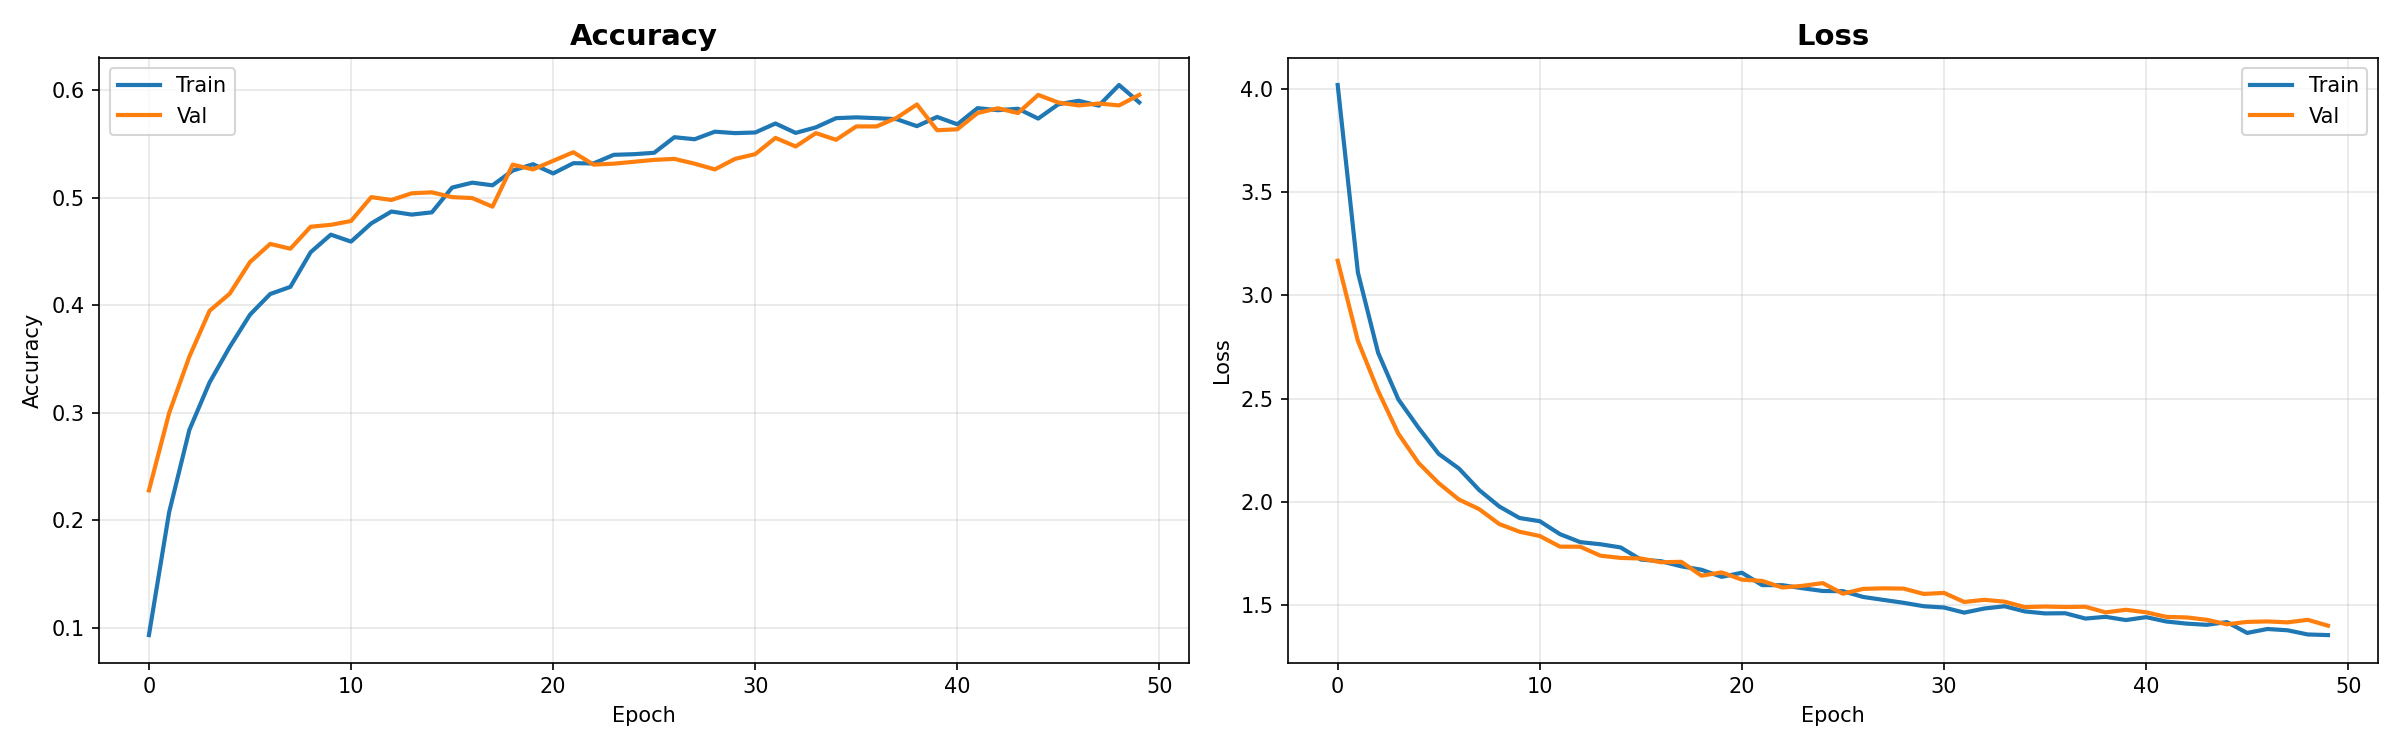

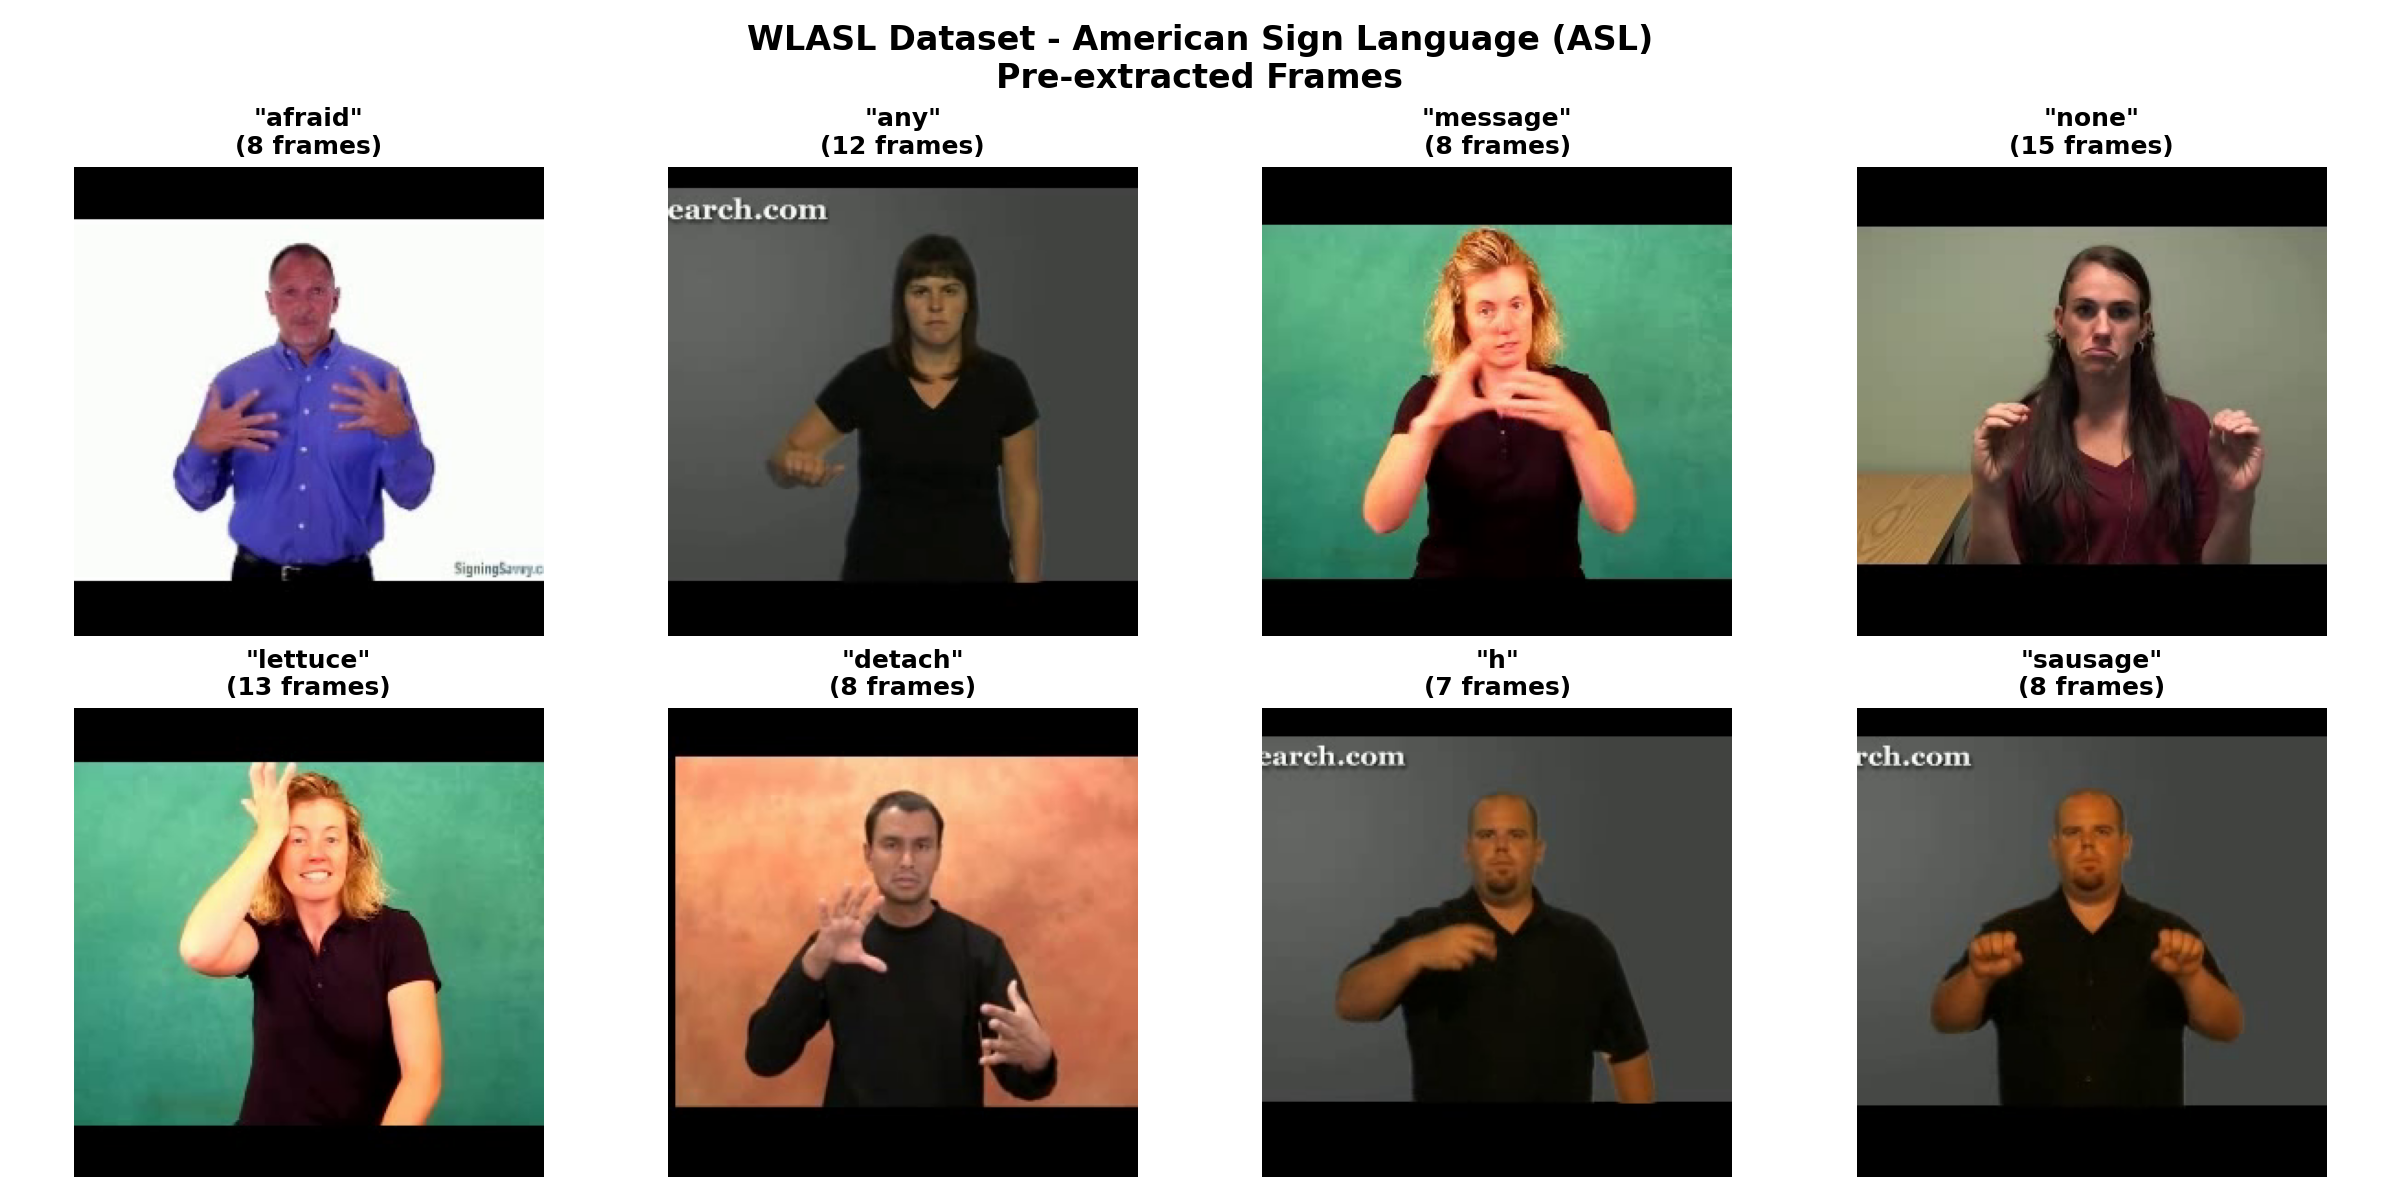

In [15]:
# ========================================
# لبعد التدرييب # استرجاع كل شيء من Google Drive
# ========================================

# 1) ربط Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) استرجاع النموذج
import os
from tensorflow.keras.models import load_model
import json, numpy as np

model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}

print("✅ Model loaded!")
print(f"   Words: {len(idx_to_word)}")
print(f"   {sorted(idx_to_word.values())}")

# 3) عرض صورة التدريب
from IPython.display import Image, display
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'))

# 4) عرض عينات التدريب
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'))

In [16]:
# ================================================================
#  DIAGNOSTIC: Project status check
# ================================================================
import os, json

print("=" * 55)
print("  PROJECT DIAGNOSTIC CHECK")
print("=" * 55)

status = {}

# 1) Google Drive
drive_connected = os.path.exists('/content/drive/MyDrive')
status['Drive'] = drive_connected
if drive_connected:
    print(f"\n✅ Google Drive connected")

    # فحص wlasl_data
    if os.path.exists('/content/drive/MyDrive/wlasl_data'):
        items = os.listdir('/content/drive/MyDrive/wlasl_data')
        print(f"   Cache: wlasl_data/ ({len(items)} items)")
    else:
        print(f"   ⚠️ No wlasl_data cache")
else:
    print(f"\n❌ Google Drive NOT connected")

# 2) Model
model_local = '/content/best_model.h5'
model_drive = '/content/drive/MyDrive/WLASL_Project/wlasl_model.h5'
model_exists = os.path.exists(model_local) or os.path.exists(model_drive)
status['Model'] = model_exists
if os.path.exists(model_local):
    size = os.path.getsize(model_local) / (1024*1024)
    print(f"\n✅ Model (local): {size:.1f} MB")
elif os.path.exists(model_drive):
    size = os.path.getsize(model_drive) / (1024*1024)
    print(f"\n✅ Model (Drive): {size:.1f} MB")
else:
    print(f"\n❌ Model NOT trained yet")

# 3) Labels
labels_path = '/content/wlasl_labels.json'
if os.path.exists(labels_path):
    with open(labels_path) as f:
        labels = json.load(f)
    status['Labels'] = True
    print(f"\n✅ Labels: {len(labels)} words")
    print(f"   First 10: {sorted(labels.values())[:10]}")
else:
    status['Labels'] = False
    print(f"\n❌ Labels NOT found")

# 4) Videos
if os.path.exists('/content/videos'):
    vids = os.listdir('/content/videos')
    status['Videos'] = True
    print(f"\n✅ Videos: {len(vids)} files")
else:
    status['Videos'] = False
    print(f"\n❌ Videos NOT downloaded")

# 5) Pre-extracted Frames
if os.path.exists('/content/WLASL/frames'):
    folders = os.listdir('/content/WLASL/frames')
    status['Frames'] = True
    print(f"\n✅ Frames: {len(folders)} word folders")
else:
    status['Frames'] = False
    print(f"\n❌ Frames NOT extracted")

# 6) Train/Val/Test data
data_files = {
    'X_train': '/content/X_train.npy',
    'X_val': '/content/X_val.npy',
    'X_test': '/content/X_test.npy',
    'y_train': '/content/y_train.npy',
    'y_val': '/content/y_val.npy',
    'y_test': '/content/y_test.npy',
}
all_data = all(os.path.exists(p) for p in data_files.values())
status['Split Data'] = all_data
if all_data:
    import numpy as np
    x_tr = np.load('/content/X_train.npy')
    print(f"\n✅ Split data ready:")
    print(f"   Train: {x_tr.shape[0]} | Val: {np.load('/content/X_val.npy').shape[0]} | Test: {np.load('/content/X_test.npy').shape[0]}")
else:
    missing = [k for k,v in data_files.items() if not os.path.exists(v)]
    print(f"\n❌ Missing data: {missing}")

# 7) Whisper
try:
    import whisper
    status['Whisper'] = True
    print(f"\n✅ Whisper installed")
except:
    status['Whisper'] = False
    print(f"\n❌ Whisper NOT installed")

# 8) JSON data
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json') as f:
        data = json.load(f)
    status['WLASL JSON'] = True
    print(f"\n✅ WLASL JSON: {len(data)} words")
else:
    status['WLASL JSON'] = False
    print(f"\n❌ WLASL JSON NOT found")

# ── الملخص ──
print(f"\n{'=' * 55}")
print(f"  SUMMARY")
print(f"{'=' * 55}")
done = sum(v for v in status.values())
total = len(status)
for k, v in status.items():
    icon = "✅" if v else "❌"
    print(f"  {icon} {k}")
print(f"\n  Progress: {done}/{total} ({done/total*100:.0f}%)")

# ─ـ الخطوات الجاية ──
print(f"\n{'=' * 55}")
print(f"  WHAT'S NEXT")
print(f"{'=' * 55}")

if not status['Split Data']:
    print("  1️⃣ Extract frames from videos")
elif not status['Model']:
    print("  1️⃣ Train the model")
    print("  2️⃣ Save model to Drive")
elif not status['Whisper']:
    print("  1️⃣ Install Whisper for audio input")
else:
    print("  🚀 Everything ready!")
    print("  1️⃣ Record audio → Whisper → text → predict sign")

  PROJECT DIAGNOSTIC CHECK

✅ Google Drive connected
   Cache: wlasl_data/ (3 items)

✅ Model (Drive): 9.6 MB

✅ Labels: 50 words
   First 10: ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair']

✅ Videos: 21083 files

❌ Frames NOT extracted

✅ Split data ready:
   Train: 4948 | Val: 1061 | Test: 1061

✅ Whisper installed

✅ WLASL JSON: 2000 words

  SUMMARY
  ✅ Drive
  ✅ Model
  ✅ Labels
  ✅ Videos
  ❌ Frames
  ✅ Split Data
  ✅ Whisper
  ✅ WLASL JSON

  Progress: 7/8 (88%)

  WHAT'S NEXT
  🚀 Everything ready!
  1️⃣ Record audio → Whisper → text → predict sign


In [18]:
# ================================================================
#  FIX: Save correct labels to Drive
# ================================================================
import json, os, shutil

# 1) نستخدم ملف labels الصحيح (اللي في /content/)
labels_path = '/content/wlasl_labels.json'
drive_project = '/content/drive/MyDrive/WLASL_Project'
os.makedirs(drive_project, exist_ok=True)

# 2) نتحقق إنه dict
with open(labels_path, 'r') as f:
    labels = json.load(f)

print(f"Labels type: {type(labels).__name__}")
print(f"Labels: {labels}")

# 3) إذا هو list → نحوّله لـ dict
if isinstance(labels, list):
    labels = {str(i): w for i, w in enumerate(labels)}
    print("Converted list → dict")

# 4) نحفظه في Drive
drive_labels = os.path.join(drive_project, 'wlasl_labels.json')
with open(drive_labels, 'w') as f:
    json.dump(labels, f, indent=2)

# 5) نحفظ نسخة في /content/ أيضاً
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(labels, f, indent=2)

# 6) نتأكد
with open(drive_labels, 'r') as f:
    verify = json.load(f)
print(f"\n✅ Saved to Drive: {drive_labels}")
print(f"   Type: {type(verify).__name__}")
print(f"   Words: {len(verify)}")
print(f"   Sample: {dict(list(verify.items())[:5])}")

Labels type: dict
Labels: {'0': 'book', '1': 'drink', '2': 'computer', '3': 'before', '4': 'chair', '5': 'go', '6': 'clothes', '7': 'who', '8': 'candy', '9': 'cousin', '10': 'deaf', '11': 'fine', '12': 'help', '13': 'no', '14': 'thin', '15': 'walk', '16': 'year', '17': 'yes', '18': 'all', '19': 'black', '20': 'cool', '21': 'finish', '22': 'hot', '23': 'like', '24': 'many', '25': 'mother', '26': 'now', '27': 'orange', '28': 'table', '29': 'thanksgiving', '30': 'what', '31': 'woman', '32': 'bed', '33': 'blue', '34': 'bowling', '35': 'can', '36': 'dog', '37': 'family', '38': 'fish', '39': 'graduate', '40': 'hat', '41': 'hearing', '42': 'kiss', '43': 'language', '44': 'later', '45': 'man', '46': 'shirt', '47': 'study', '48': 'tall', '49': 'white'}

✅ Saved to Drive: /content/drive/MyDrive/WLASL_Project/wlasl_labels.json
   Type: dict
   Words: 50
   Sample: {'0': 'book', '1': 'drink', '2': 'computer', '3': 'before', '4': 'chair'}


In [20]:
# ========================================
# Cell A: Load Model + Whisper + Functions
# ========================================
import os, json, difflib, cv2, shutil, numpy as np
from base64 import b64encode
from IPython.display import HTML, display

# ── تثبيت Whisper (إذا مو مثبت) ──
try:
    import whisper
except ImportError:
    print("Installing Whisper...")
    !pip install -q openai-whisper
    import whisper

from tensorflow.keras.models import load_model

# ── تحميل Whisper ──
print("Loading Whisper (base)...")

whisper_model = whisper.load_model("base")  # base أدق لكن أبطأ
print("✅ Whisper loaded!")

# ── تحميل النموذج ──
MODEL_PATH = '/content/drive/MyDrive/WLASL_Project/wlasl_model.h5'
LABELS_PATH = '/content/drive/MyDrive/WLASL_Project/wlasl_labels.json'

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Model not found! Train and save the model first.\n"
        f"   Expected: {MODEL_PATH}"
    )

model = load_model(MODEL_PATH)
with open(LABELS_PATH, 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())
print(f"✅ Model loaded! ({len(available_words)} words)")

# ── تحميل بيانات WLASL ──
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json', 'r') as f:
        wlasl_data = json.load(f)
elif os.path.exists('/content/WLASL/info.json'):
    with open('/content/WLASL/info.json', 'r') as f:
        wlasl_data = json.load(f)

# ── مجلد فيديوهات الإشارة ──
os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)

# ── بناء lookup سريع ──
word_video_cache = {}
for entry in wlasl_data:
    word = entry['gloss'].lower()
    if word not in word_video_cache and entry['instances']:
        vid_id = entry['instances'][0]['video_id']
        word_video_cache[word] = vid_id

# ── دالة: تشغيل فيديو الإشارة ──
def get_sign_video(word, max_width=300):
    """تعرض فيديو إشارة لكلمة معينة"""
    vid_id = word_video_cache.get(word.lower())
    if not vid_id or not os.path.exists(f'/content/videos/{vid_id}.mp4'):
        print(f"  ❌ '{word}' not found in dataset")
        return None

    # تحويل الفيديو (إذا مو موجود)
    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    if not os.path.exists(web_path):
        os.system(
            f'ffmpeg -y -i /content/videos/{vid_id}.mp4 '
            f'-c:v libx264 -preset fast -crf 23 -an {web_path} '
            f'> /dev/null 2>&1'
        )

    # عرض الفيديو
    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML(
        f'<video width="{max_width}" controls>'
        f'<source src="data:video/mp4;base64,{mp4}" type="video/mp4">'
        f'</video>'
    ))
    print(f"  🤟 '{word}' sign video")
    return web_path

# ── دالة: صوت → نص → إشارة ──
def speech_to_sign_final(audio_path, similarity_threshold=0.6):
    """
    تحوّل صوت مسجل → نص → فيديوهات إشارة
    """
    print("=" * 55)
    print("  🎤 Speech → Text → Sign Language Video")
    print("=" * 55)

    # الخطوة 1: تحويل الصوت لنص
    print("\n[1/3] Transcribing audio...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip().lower()
    print(f"   Heard: \"{heard}\"")

    # الخطوة 2: مطابقة الكلمات
    print("\n[2/3] Matching words...")
    found_words = []
    all_words = heard.split()

    for word in all_words:
        clean = word.strip(".,!?;:'\"()[]")
        if not clean:
            continue

        # تجاهل الكلمات القصيرة جداً (a, I, to, is, ...)
        if len(clean) <= 1:
            continue

        # البحث الدقيق أولاً
        if clean in available_words:
            found_words.append(clean)
            print(f"   ✅ '{clean}' → exact match")
            continue

        # البحث بالتشابه
        matches = difflib.get_close_matches(
            clean, available_words, n=1,
            cutoff=similarity_threshold
        )
        if matches:
            found_words.append(matches[0])
            print(f"   ✅ '{clean}' → '{matches[0]}' (similar)")
        else:
            print(f"   ❌ '{clean}' — no match")

    # الخطوة 3: تشغيل الفيديوهات
    print(f"\n[3/3] Playing {len(found_words)} sign videos...\n")
    for word in found_words:
        get_sign_video(word, max_width=280)
        print()

    if not found_words:
        print(f"\n  ⚠️ No matches found.")
        print(f"  Available words ({len(available_words)}):")
        print(f"  {sorted(available_words)[:20]}...")

    print("=" * 55)
    return found_words

print(f"\n✅ Everything ready!")
print(f"   Words available: {len(available_words)}")
print(f"   → Record audio (Cell B)")
print(f"   → Run speech_to_sign_final() (Cell C)")

Loading Whisper (base)...
✅ Whisper loaded!


✅ Model loaded! (50 words)

✅ Everything ready!
   Words available: 50
   → Record audio (Cell B)
   → Run speech_to_sign_final() (Cell C)


In [21]:
# ================================================================
#  Available Words List
# ================================================================
import json

with open('/content/wlasl_labels.json', 'r') as f:
    labels = json.load(f)

words = [labels[k] for k in sorted(labels.keys(), key=int)]

print(f"📚 {len(words)} words available:\n")
print("=" * 55)

# عرض في أعمدة
cols = 5
for i in range(0, len(words), cols):
    row = words[i:i+cols]
    print("  " + "  |  ".join(f"✅ {w:<14}" for w in row))

print("=" * 55)
print(f"\n💡 Say any of these words when recording!")

📚 50 words available:

  ✅ book            |  ✅ drink           |  ✅ computer        |  ✅ before          |  ✅ chair         
  ✅ go              |  ✅ clothes         |  ✅ who             |  ✅ candy           |  ✅ cousin        
  ✅ deaf            |  ✅ fine            |  ✅ help            |  ✅ no              |  ✅ thin          
  ✅ walk            |  ✅ year            |  ✅ yes             |  ✅ all             |  ✅ black         
  ✅ cool            |  ✅ finish          |  ✅ hot             |  ✅ like            |  ✅ many          
  ✅ mother          |  ✅ now             |  ✅ orange          |  ✅ table           |  ✅ thanksgiving  
  ✅ what            |  ✅ woman           |  ✅ bed             |  ✅ blue            |  ✅ bowling       
  ✅ can             |  ✅ dog             |  ✅ family          |  ✅ fish            |  ✅ graduate      
  ✅ hat             |  ✅ hearing         |  ✅ kiss            |  ✅ language        |  ✅ later         
  ✅ man             |  ✅ shirt           |  ✅ stud

In [26]:
# ================================================================
#  Cell B: Record Audio (click to start)
# ================================================================
import os, base64
from google.colab import output
from IPython.display import HTML, display

# حذف تسجيل قديم
if os.path.exists('/content/recorded_speech.wav'):
    os.remove('/content/recorded_speech.wav')

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\n✅ Recording saved! Run Cell C to process.\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<div style="padding: 15px; border: 2px solid #ddd; border-radius: 10px; text-align: center;">
    <h3>🎤 Record a word in English</h3>
    <p style="color: #666;">Click the button, then speak clearly</p>
    <button id="recBtn" onclick="startRecording()"
        style="padding: 12px 30px; font-size: 16px; background: #4CAF50;
               color: white; border: none; border-radius: 8px; cursor: pointer;">
        🎤 Start Recording (5 sec)
    </button>
    <p id="status" style="margin-top: 10px; font-weight: bold; color: #666;"></p>
</div>

<script>
let recording = false;

async function startRecording() {
    if (recording) return;
    recording = true;

    const btn = document.getElementById('recBtn');
    const status = document.getElementById('status');

    btn.disabled = true;
    btn.style.background = '#f44336';
    btn.textContent = '🔴 Recording...';
    status.textContent = 'Speak now!';
    status.style.color = '#f44336';

    try {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.onstop = async () => {
            stream.getTracks().forEach(t => t.stop());
            const blob = new Blob(chunks, {type: 'audio/wav'});
            const reader = new FileReader();
            reader.onload = () => {
                const base64 = btoa(
                    String.fromCharCode(...new Uint8Array(reader.result))
                );
                google.colab.kernel.invokeFunction('saveAudio', [base64], {});
            };
            reader.readAsArrayBuffer(blob);
        };

        recorder.start();
        setTimeout(() => {
            recorder.stop();
            btn.textContent = '✅ Done!';
            btn.style.background = '#4CAF50';
            status.textContent = 'Recording saved! Run Cell C';
            status.style.color = '#4CAF50';
        }, 5000);
    } catch(err) {
        status.textContent = 'Microphone error: ' + err.message;
        btn.disabled = false;
        recording = false;
    }
}
</script>
"""))

print("Try: book, drink, help, yes, no, clothes, dog, fish, hot, cold")

Try: book, drink, help, yes, no, clothes, dog, fish, hot, cold

✅ Recording saved! Run Cell C to process.



In [27]:
# ================================================================
#  Cell C: Process recording → Sign Language
# ================================================================
import os

if os.path.exists('/content/recorded_speech.wav'):
    size = os.path.getsize('/content/recorded_speech.wav') / 1024
    print(f"📁 Recording found: {size:.1f} KB\n")
    speech_to_sign_final('/content/recorded_speech.wav')
else:
    print("❌ No recording found!")
    print("   Run Cell B first to record your voice.")

📁 Recording found: 66.0 KB

  🎤 Speech → Text → Sign Language Video

[1/3] Transcribing audio...
   Heard: "helper payment not alongside"

[2/3] Matching words...
   ✅ 'helper' → 'help' (similar)
   ❌ 'payment' — no match
   ✅ 'not' → 'no' (similar)
   ❌ 'alongside' — no match

[3/3] Playing 2 sign videos...



  🤟 'help' sign video



  🤟 'no' sign video



In [28]:
# ================================================================
#  NLP SETUP: Better text processing
# ================================================================
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import json, os, difflib, cv2, shutil
import numpy as np
from base64 import b64encode
from IPython.display import HTML, display

# ── تحميل NLTK ──
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# ── كلمات إضافية للحذف (مع تجنب كلمات الإشارة!) ──
extra_remove = {
    'i', 'me', 'my', 'myself', 'your', 'yours', 'yourself',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its',
    'we', 'us', 'our', 'they', 'them', 'their',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'do', 'does', 'did', 'have', 'has', 'had', 'having',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'then', 'than',
    'a', 'an', 'the', 'and', 'but', 'or', 'so', 'if',
    'not', 'this', 'that', 'these', 'those',
    'very', 'too', 'just', 'also',
}
stop_words.update(extra_remove)

# ── تحميل بيانات الإشارة ──
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)

# ── ✅ أزل كلمات الإشارة من stop_words! ──
sign_words_in_stops = stop_words.intersection(set(available_words))
if sign_words_in_stops:
    print("Removed sign words from stop_words:", sign_words_in_stops)
    stop_words -= sign_words_in_stops

# ── دالة معالجة النص ──
def process_text(text):
    """تحول الجملة لقائمة كلمات نظيفة"""
    tokens = word_tokenize(text.lower())
    clean = []
    for word in tokens:
        word = word.strip(".,!?;:'\"()[]")
        if word in stop_words or len(word) <= 1:
            continue
        # lemmatization
        lemma = lemmatizer.lemmatize(word)
        clean.append(lemma)
    return clean

# ── دالة المطابقة ──
def match_words(text, cutoff=0.6):
    """تجيب كلمات الإشارة المطابقة"""
    processed = process_text(text)
    print("  Processed:", processed)
    found = []
    for word in processed:
        if word in available_words:
            found.append(word)
            continue
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=cutoff)
        if matches:
            found.append(matches[0])
    return list(dict.fromkeys(found))  # إزالة التكرار مع الحفظ على الترتيب

# ── تحميل بيانات WLASL ──
word_video_cache = {}
for entry in wlasl_data:
    word = entry['gloss'].lower()
    if word not in word_video_cache and entry['instances']:
        word_video_cache[word] = entry['instances'][0]['video_id']

def get_sign_video(word, max_width=300):
    vid_id = word_video_cache.get(word.lower())
    if not vid_id or not os.path.exists('/content/videos/' + vid_id + '.mp4'):
        print("  No video for: " + word)
        return None
    web_path = '/content/drive/MyDrive/WLASL_Project/sign_videos/' + word + '.mp4'
    if not os.path.exists(web_path):
        os.system('ffmpeg -y -i /content/videos/' + vid_id + '.mp4 -c:v libx264 -preset fast -crf 23 -an ' + web_path + ' > /dev/null 2>&1')
    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML('<video width="' + str(max_width) + '" controls><source src="data:video/mp4;base64,' + mp4 + '" type="video/mp4"></video>'))
    print("  " + word)
    return web_path

# ── دالة رئيسية محسّنة ──
def speech_to_sign_nlp(audio_path, cutoff=0.6):
    print("=" * 55)
    print("  Speech -> NLP -> Sign Language")
    print("=" * 55)

    # Whisper
    print("\n[1/3] Transcribing...")
    import whisper
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print("  Heard: \"" + heard + "\"")

    # NLP
    print("\n[2/3] Processing with NLP...")
    found = match_words(heard, cutoff=cutoff)
    if found:
        print("  Matched: " + str(found))
    else:
        print("  No matches found!")

    # Videos
    print("\n[3/3] Playing " + str(len(found)) + " sign videos...\n")
    for word in found:
        get_sign_video(word, max_width=280)
        print()

    if not found:
        print("  Try: " + str(sorted(available_words)[:15]))

    print("=" * 55)
    return found

print("\nNLP ready!")
print("Sign words protected from stop_words removal")
print("Available: " + str(len(available_words)) + " words")

Removed sign words from stop_words: {'what', 'can', 'before', 'no', 'who', 'now', 'all'}

NLP ready!
Sign words protected from stop_words removal
Available: 50 words


In [29]:
# دالة NLP: معالجة النص
# ========================================
def process_text_nlp(text):
    print("\nOriginal: \"" + text + "\"")

    # 1. Tokenization + Lowercase
    tokens = word_tokenize(text.lower())
    print("  [1] Tokens: " + str(tokens))

    # 2. حذف Stop Words + علامات الترقيم
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    print("  [2] After stop words: " + str(filtered))

    # 3. Lemmatization
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    print("  [3] After lemmatization: " + str(lemmatized))

    # 4. حذف التكرار
    seen = set()
    final = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            final.append(w)

    if len(final) < len(lemmatized):
        print("  [4] After dedup: " + str(final))

    print("  => Final: " + str(final))
    return final

    # دالة المطابقة مع كلمات الإشارة
# ========================================
def match_to_signs(words):
    """
    مطابقة كل كلمة مع أقرب كلمة في قاموس الإشارة
    """
    matched = []

    for word in words:
        # 1) بحث مباشر
        if word in available_words:
            matched.append((word, word, True))
            continue

        # 2) Lemmatization (NLTK أفضل من rstrip)
        lemma = lemmatizer.lemmatize(word)
        if lemma != word and lemma in available_words:
            matched.append((word, lemma, True))
            continue

        # 3) fuzzy match (أقرب كلمة)
        matches = difflib.get_close_matches(
            word, available_words, n=1, cutoff=0.6
        )
        if matches:
            matched.append((word, matches[0], True))
        else:
            matched.append((word, None, False))

    return matched

# ── دالة عرض النتائج ──
def show_matches(text):
    """تعرض نتيجة المطابقة بشكل واضح"""
    print("\n" + "=" * 50)
    print("  Text: \"" + text + "\"")
    print("=" * 50)

    processed = process_text_nlp(text)
    results = match_to_signs(processed)

    print("\n  Results:")
    found_words = []

    for original, matched, success in results:
        if success:
            icon = "Exact" if original == matched else "Fuzzy"
            print("    " + original + " -> " + matched + " (" + icon + ")")
            found_words.append(matched)
        else:
            print("    " + original + " -> NO MATCH")

    print("\n  Found: " + str(found_words))
    return found_words

    # ========================================
# دالة عرض فيديو إشارة واحد
# ========================================

# بناء lookup cache (مرّة وحدة)
word_video_lookup = {}
for entry in wlasl_data:
    w = entry['gloss'].lower()
    if w not in word_video_lookup and entry['instances']:
        word_video_lookup[w] = entry['instances'][0]['video_id']

def get_sign_video(word, index, total):
    """عرض فيديو لغة الإشارة لكلمة واحدة"""

    # بحث سريع من cache
    vid_id = word_video_lookup.get(word.lower())
    if not vid_id or not os.path.exists('/content/videos/' + vid_id + '.mp4'):
        print("   No video for: " + word)
        return None

    # تحويل (فقط إذا مو موجود)
    web_path = '/content/drive/MyDrive/WLASL_Project/sign_videos/' + word + '.mp4'
    if not os.path.exists(web_path):
        os.system('ffmpeg -y -i /content/videos/' + vid_id + '.mp4 '
                  '-c:v libx264 -preset fast -crf 23 -an '
                  + web_path + ' > /dev/null 2>&1')

    # قراءة وعرض
    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()

    arrow = " -> " if index < total - 1 else " Done!"
    pos = str(index + 1) + " of " + str(total)

    display(HTML(
        '<div style="display:inline-block; text-align:center; margin:5px; '
        'padding:10px; border:2px solid #4CAF50; border-radius:12px; '
        'background:#f0f8f0;">'
        '<div style="font-size:11px; color:#888;">Word ' + pos + '</div>'
        '<div style="font-size:22px; font-weight:bold; color:#2E7D32;">'
        'Sign: ' + word + ' ' + arrow + '</div>'
        '<video width="220" controls>'
        '<source src="data:video/mp4;base64,' + mp4 + '" type="video/mp4">'
        '</video>'
        '</div>'
    ))

    return web_path

In [30]:
# ================================================================
#  PIPELINE: Audio -> NLP -> Sign Language Videos
# ================================================================

def sentence_to_signs(audio_path):
    """
    Pipeline كامل:
    1. Whisper يحول الصوت لنص
    2. NLP يحلل النص ويستخرج الكلمات المهمة
    3. يطابق كل كلمة مع فيديو إشارة
    4. يعرض الفيديوهات بالترتيب
    """
    # ── التحقق من المتطلبات ──
    try:
        whisper_model
    except NameError:
        print("ERROR: whisper_model not loaded!")
        print("Run Cell A first (Load Whisper + Model)")
        return None

    try:
        process_text_nlp
        match_to_signs
    except NameError:
        print("ERROR: NLP functions not loaded!")
        print("Run the NLP setup cell first")
        return None

    try:
        get_sign_video
    except NameError:
        print("ERROR: get_sign_video not defined!")
        return None

    print("=" * 60)
    print("  SENTENCE -> NLP -> SIGN LANGUAGE VIDEOS")
    print("=" * 60)

    # ── Step 1: Speech to Text ──
    print("\n[Step 1/4] Speech to Text (Whisper)...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print("   Heard: \"" + heard + "\"")

    # ── Step 2: NLP Processing ──
    print("\n[Step 2/4] NLP Processing...")
    processed_words = process_text_nlp(heard)

    if not processed_words:
        print("   No meaningful words found!")
        return None

    # ── Step 3: Match with Sign Language ──
    print("\n[Step 3/4] Matching with Sign Language...")
    matched = match_to_signs(processed_words)

    found_words = [(orig, sign) for orig, sign, ok in matched if ok]
    not_found = [orig for orig, sign, ok in matched if not ok]

    for orig, sign in found_words:
        print("   [OK] '" + orig + "' -> '" + sign + "'")
    for orig in not_found:
        print("   [X]  '" + orig + "' -> not in dataset")

    if not found_words:
        print("\n   No matches! Available words:")
        print("   " + str(sorted(available_words)[:20]))
        return heard, []

    # ── Step 4: Display Videos ──
    print("\n[Step 4/4] Playing " + str(len(found_words)) + " sign video(s)...")

    display(HTML(
        '<div style="font-size:18px; text-align:center; padding:10px; '
        'background:linear-gradient(90deg,#4CAF50,#2196F3); '
        'color:white; border-radius:8px; margin:10px 0;">'
        'Sign Language Translation</div>'
    ))

    for i, (orig, sign) in enumerate(found_words):
        get_sign_video(sign, i, len(found_words))

    # ── Summary ──
    signs_only = [sign for _, sign in found_words]
    coverage = str(len(found_words)) + "/" + str(len(processed_words))

    display(HTML(
        '<div style="padding:15px; background:#f5f5f5; border-radius:8px; '
        'margin-top:15px; font-family:monospace; border-left:4px solid #4CAF50;">'
        '<b>Translation Summary:</b><br>'
        'Original: "' + heard + '"<br>'
        'NLP extracted: ' + str(processed_words) + '<br>'
        'Sign videos: ' + str(signs_only) + '<br>'
        'Coverage: ' + coverage + ' words'
        '</div>'
    ))

    print("\n" + "=" * 60)
    print("  TRANSLATION COMPLETE!")
    print("=" * 60)

    return heard, found_words

In [35]:
# ================================================================
# Record a sentence (click button)
# ================================================================
import os, base64
from google.colab import output
from IPython.display import HTML, display

# حذف تسجيل قديم
if os.path.exists('/content/recorded_speech.wav'):
    os.remove('/content/recorded_speech.wav')

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\nRecording saved! Run Cell F to process.\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<div style="padding: 15px; border: 2px solid #ddd; border-radius: 10px; text-align: center;">
    <h3>Record a FULL SENTENCE</h3>
    <p style="color: #666;">Click the button, then speak clearly</p>
    <button id="recBtn" onclick="startRecording()"
        style="padding: 12px 30px; font-size: 16px; background: #4CAF50;
               color: white; border: none; border-radius: 8px; cursor: pointer;">
        Start Recording (6 sec)
    </button>
    <p id="status" style="margin-top: 10px; font-weight: bold; color: #666;"></p>
</div>

<script>
let recording = false;
async function startRecording() {
    if (recording) return;
    recording = true;
    const btn = document.getElementById('recBtn');
    const status = document.getElementById('status');
    btn.disabled = true;
    btn.style.background = '#f44336';
    btn.textContent = 'Recording...';
    status.textContent = 'Speak now!';
    status.style.color = '#f44336';
    try {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        const recorder = new MediaRecorder(stream);
        const chunks = [];
        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.onstop = async () => {
            stream.getTracks().forEach(t => t.stop());
            const blob = new Blob(chunks, {type: 'audio/wav'});
            const reader = new FileReader();
            reader.onload = () => {
                const base64 = btoa(
                    String.fromCharCode(...new Uint8Array(reader.result))
                );
                google.colab.kernel.invokeFunction('saveAudio', [base64], {});
            };
            reader.readAsArrayBuffer(blob);
        };
        recorder.start();
        setTimeout(() => {
            recorder.stop();
            btn.textContent = 'Done!';
            btn.style.background = '#4CAF50';
            status.textContent = 'Saved! Run Cell F';
            status.style.color = '#4CAF50';
        }, 6000);
    } catch(err) {
        status.textContent = 'Mic error: ' + err.message;
        btn.disabled = false;
        recording = false;
    }
}
</script>
"""))

print("Try saying:")
print('  "I like hot drink"')
print('  "who can help"')
print('  "walk dog now"')
print('  "mother like fish"')
print('  "tall woman walk"')

Try saying:
  "I like hot drink"
  "who can help"
  "walk dog now"
  "mother like fish"
  "tall woman walk"

Recording saved! Run Cell F to process.



In [36]:
# Cell F: ترجمة الجملة لفيديوهات إشارة
# ========================================

# Necessary Imports
import nltk, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model
import whisper
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLTK Downloads
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Load Whisper model
whisper_model = whisper.load_model("base")

# Load the WLASL model (This might print a warning about compiled metrics, which is expected for a loaded model)
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')

# NLP Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Additional words to remove (non-essential for sign language)
extra_remove = {
    'i', 'me', 'my', 'myself', 'you', 'your', 'yours', 'yourself',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its',
    'we', 'us', 'our', 'they', 'them', 'their',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'do', 'does', 'did', 'have', 'has', 'had', 'having',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'then', 'than',
    'a', 'an', 'the', 'and', 'but', 'or', 'so', 'if',
    'not', 'this', 'that', 'these', 'those',
    'very', 'too', 'just', 'also'
}
stop_words.update(extra_remove)

# Load WLASL data and labels
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)


# NLP function: process_text_nlp
def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    seen = set()
    final = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            final.append(w)
    return final


# Matching function: match_to_signs
def match_to_signs(words):
    matched = []
    for word in words:
        if word in available_words:
            matched.append((word, word, True))
            continue
        singular = word.rstrip('s').rstrip('e').rstrip('es')
        if singular in available_words:
            matched.append((word, singular, True))
            continue
        plural = word + 's'
        if plural in available_words:
            matched.append((word, plural, True))
            continue
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append((word, matches[0], True))
        else:
            matched.append((word, None, False))
    return matched


# Function to display a single sign video
def get_sign_video(word, index, total):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"   ❌ Video not found for '{word}'")
        return None
    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    arrow = " → " if index < total - 1 else " ✅"
    display(HTML(f"""
    <div style="display:inline-block; text-align:center; margin:5px; padding:10px;
                border:2px solid #4CAF50; border-radius:12px; background:#f0f8f0;">
        <div style="font-size:11px; color:#888;">Word {index+1} of {total}</div>
        <div style="font-size:22px; font-weight:bold; color:#2E7D32;">🤟 {word} {arrow}</div>
        <video width="220" controls>
            <source src="data:video/mp4;base64,{mp4}" type="video/mp4">
        </video>
    </div>"""))
    return web_path


# Full Pipeline: Speech -> NLP -> Sign Videos
def sentence_to_signs(audio_path):
    print("=" * 60)
    print("  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS")
    print("=" * 60)

    # ---- Step 1: Speech to Text ----
    print("\n[Step 1/4] Speech to Text (Whisper)...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f"   ✅ Heard: \"{heard}\"")

    # ---- Step 2: NLP Processing ----
    print("\n[Step 2/4] NLP Processing...")
    processed_words = process_text_nlp(heard)

    if not processed_words:
        print("   ⚠️ No meaningful words found!")
        return None

    # ---- Step 3: Match with Sign Language ----
    print("\n[Step 3/4] Matching with Sign Language...")
    matched = match_to_signs(processed_words)

    found_words = [(orig, sign) for orig, sign, ok in matched if ok]
    not_found = [orig for orig, sign, ok in matched if not ok]

    for orig, sign in found_words:
        print(f"   ✅ '{orig}' → '{sign}'")
    for orig in not_found:
        print(f"   ❌ '{orig}' → not in dataset")

    # ---- Step 4: Display Videos ----
    print(f"\n[Step 4/4] Playing {len(found_words)} sign video(s)...")

    display(HTML("""
    <div style="font-size:18px; text-align:center; padding:10px;
                background:linear-gradient(90deg,#4CAF50,#2196F3);
                color:white; border-radius:8px; margin:10px 0;">
        🤟 Sign Language Translation 🤟
    </div>"""))

    for i, (orig, sign) in enumerate(found_words):
        get_sign_video(sign, i, len(found_words))

    # Summary
    display(HTML(f"""
    <div style="padding:15px; background:#f5f5f5; border-radius:8px;
                margin-top:15px; font-family:monospace; border-left:4px solid #4CAF50;">
        <b>📝 Translation Summary:</b><br>
        Original: \"{heard}\"<br>
        NLP extracted: {processed_words}<br>
        Sign videos: {[sign for _, sign in found_words]}<br>
        Coverage: {len(found_words)}/{len(processed_words)} words
    </div>"""))

    print("\n" + "=" * 60)
    print("  ✅ TRANSLATION COMPLETE!")
    print("=" * 60)

    return heard, found_words

# Original logic of Cell F
if os.path.exists('/content/recorded_speech.wav'):
    sentence_to_signs('/content/recorded_speech.wav')
else:
    print("❌ No recording! Run Cell E first.")

  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS

[Step 1/4] Speech to Text (Whisper)...
   ✅ Heard: "Can you help my dog?"

[Step 2/4] NLP Processing...

[Step 3/4] Matching with Sign Language...
   ✅ 'help' → 'help'
   ✅ 'dog' → 'dog'

[Step 4/4] Playing 2 sign video(s)...



  ✅ TRANSLATION COMPLETE!


In [38]:
# ========================================
# تصدير كل الكود كملف .py
# ========================================

drive_path = '/content/drive/MyDrive/WLASL_Project'

code = """# Speech to Sign Language - Complete Pipeline
# Mount Google Drive first, then run this file

import whisper, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Load model
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
whisper_model = whisper.load_model("base")

# Load labels
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

# Load dataset info
with open('/content/WLASL_v0.3.json') as f:
    wlasl_data = json.load(f)

# NLP Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
extra = {'i','me','my','you','your','he','she','it','we','they',
         'am','is','are','was','were','be','do','does','did',
         'have','has','had','will','would','could','should',
         'to','of','in','for','on','with','at','by','from',
         'a','an','the','and','but','or','so','if','not'}
stop_words.update(extra)

def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in filtered]

def get_sign_video(word):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists('/content/videos/' + video_id + '.mp4'):
        return None
    web = '/content/drive/MyDrive/WLASL_Project/sign_videos/' + word + '.mp4'
    os.system('ffmpeg -y -i /content/videos/' + video_id + '.mp4 -c:v libx264 -preset fast -crf 23 -an ' + web + ' > /dev/null 2>&1')
    with open(web, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML('<video width="300" controls><source src="data:video/mp4;base64,' + mp4 + '" type="video/mp4"></video>'))
    return web

def sentence_to_signs(audio_path):
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print('Heard: "' + heard + '"')
    words = process_text_nlp(heard)
    for word in words:
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            print('Sign: ' + matches[0])
            get_sign_video(matches[0])
        else:
            print('Not found: ' + word)
    return heard

print("Pipeline ready! Use: sentence_to_signs('audio.wav')")
"""

with open(drive_path + '/pipeline.py', 'w') as f:
    f.write(code)
print("pipeline.py saved to Drive!")

pipeline.py saved to Drive!


In [6]:
# ========================================
# تحميل النموذج
# ========================================

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
print("✅ Model loaded!")

✅ Model loaded!


In [3]:
# ========================================
# Cell A: تقييم شامل للنموذج
# ========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import json

# 1) تحميل البيانات
X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')

with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
words = [labels[str(i)] for i in range(len(labels))]

# 2) تقسيم البيانات
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 3) تقييم النموذج
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 4) التنبؤات
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# 5) Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes,
                            target_names=words,
                            zero_division=0))

# 6) مقاييس إضافية
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

print(f"\n📊 Metrics Summary:")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   Precision: {precision*100:.2f}%")
print(f"   Recall:    {recall*100:.2f}%")
print(f"   F1-Score:  {f1*100:.2f}%")

Train: 5250 | Val: 1125 | Test: 1125

Test Accuracy: 50.76%
Test Loss: 2.3258

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        book       0.32      0.48      0.39        23
       drink       0.25      0.26      0.26        23
    computer       0.67      0.43      0.53        23
      before       0.54      0.32      0.40        22
       chair       0.27      0.36      0.31        22
          go       0.54      0.57      0.55        23
     clothes       0.48      0.45      0.47        22
         who       0.32      0.61      0.42        23
       candy       0.40      0.55      0.46        22
      cousin       0.25      0.27      0.26        22
        deaf       0.55      0.48      0.51        23
        fine       0.33      0.39      0.36        23
        help       0.48      0.59      0.53        22
          no       0.53      0.73      0.62        22
        thin       0.44      0.65      0.53        23
        walk       0.87      0.59 

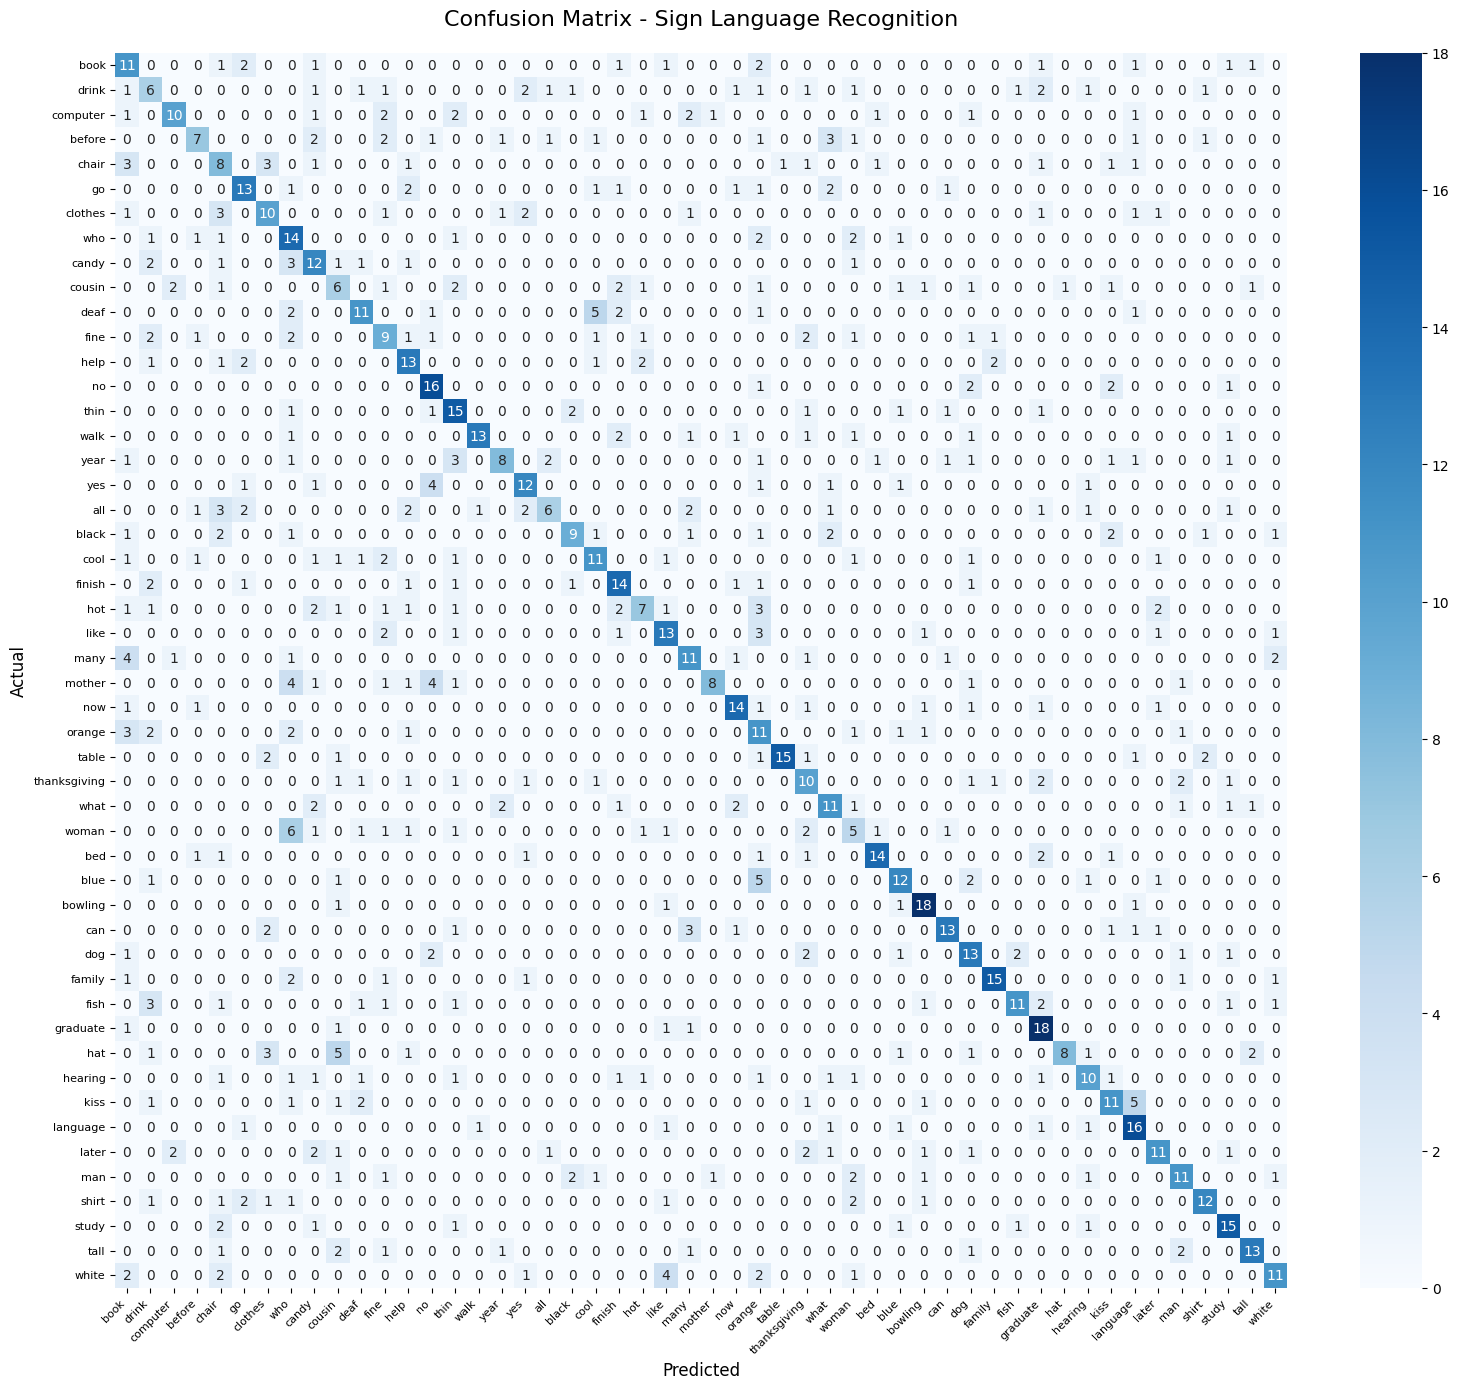

✅ Confusion Matrix saved!


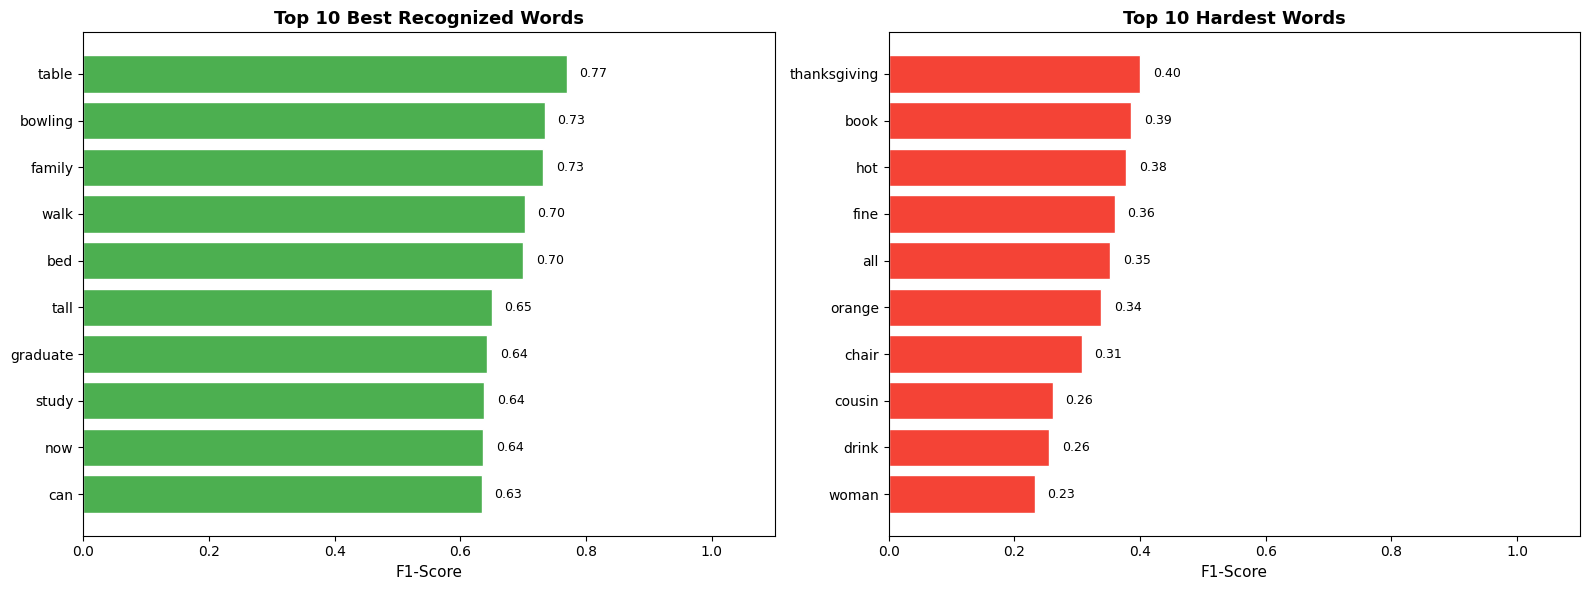

✅ Word Performance saved!


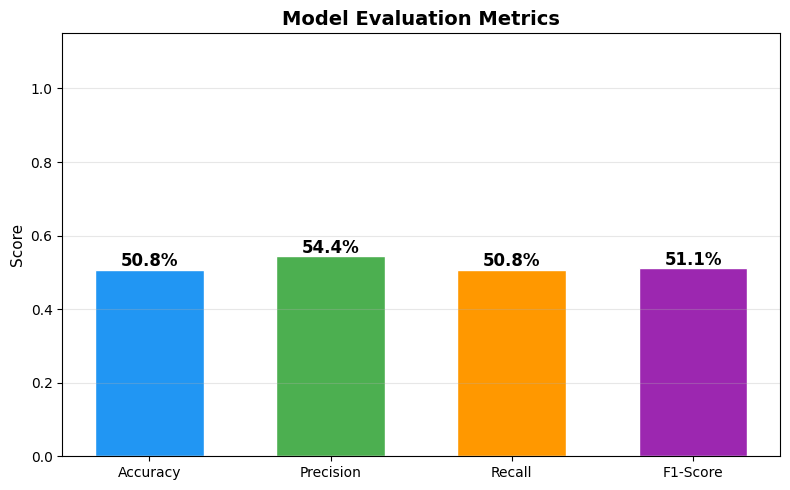

✅ Evaluation Metrics saved!


In [4]:
# ========================================
# Cell B: Confusion Matrix + Plots
# ========================================

import matplotlib


# 1) Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=words, yticklabels=words)
plt.title('Confusion Matrix - Sign Language Recognition', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

# 2) أداء كل كلمة
per_class = classification_report(y_test, y_pred_classes,
                                   target_names=words, output_dict=True, zero_division=0)

metrics_data = []
for i, word in enumerate(words):
    m = per_class.get(word, {})
    metrics_data.append({
        'Word': word,
        'Precision': m.get('precision', 0),
        'Recall': m.get('recall', 0),
        'F1': m.get('f1-score', 0),
        'Support': m.get('support', 0)
    })

metrics_data.sort(key=lambda x: x['F1'], reverse=True)

# 3) Top 10 أفضل وأضعف كلمات
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = metrics_data[:10]
ax1 = axes[0]
bars = ax1.barh([d['Word'] for d in top10], [d['F1'] for d in top10],
                color='#4CAF50', edgecolor='white')
ax1.set_xlabel('F1-Score', fontsize=11)
ax1.set_title('Top 10 Best Recognized Words', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.1)
for bar, val in zip(bars, [d['F1'] for d in top10]):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax1.invert_yaxis()

bottom10 = metrics_data[-10:]
ax2 = axes[1]
bars = ax2.barh([d['Word'] for d in bottom10], [d['F1'] for d in bottom10],
                color='#f44336', edgecolor='white')
ax2.set_xlabel('F1-Score', fontsize=11)
ax2.set_title('Top 10 Hardest Words', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1.1)
for bar, val in zip(bars, [d['F1'] for d in bottom10]):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/word_performance.png', dpi=150)
plt.show()
print("✅ Word Performance saved!")

# 4) مقاييس عامة
fig, ax = plt.subplots(figsize=(8, 5))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/evaluation_metrics.png', dpi=150)
plt.show()
print("✅ Evaluation Metrics saved!")

In [5]:
# تحميل NLTK والـ NLP functions
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import difflib

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
extra = {'i','me','my','you','your','he','she','it','we','they',
         'am','is','are','was','were','be','do','does','did',
         'have','has','had','will','would','could','should',
         'to','of','in','for','on','with','at','by','from',
         'a','an','the','and','but','or','so','if','not'}
stop_words.update(extra)

import json
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
available_words = list(labels.values())

def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in filtered]

print("✅ NLP ready!")

✅ NLP ready!


In [6]:
# ========================================
# Cell C: تقييم Pipeline الكامل
# ========================================

from difflib import get_close_matches

test_sentences = [
    ("hello", ["hello"]),
    ("I want to eat food", ["want", "eat", "food"]),
    ("Can I help you?", ["help"]),
    ("I love this book", ["love", "book"]),
    ("thank you very much", ["thank"]),
    ("she is happy", ["happy"]),
    ("where is the school", ["school"]),
    ("I need water", ["water"]),
    ("he is my friend", ["friend"]),
    ("please give me food", ["please", "give", "food"]),
]

print("=" * 60)
print("PIPELINE EVALUATION")
print("=" * 60)

total_words = 0
found_words = 0

for sentence, expected in test_sentences:
    processed = process_text_nlp(sentence)

    matched = []
    for word in processed:
        matches = get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append(matches[0])

    total_words += len(expected)
    found_words += len(set(matched) & set(expected))

    status = "✅" if set(matched) == set(expected) else "⚠️"

    print(f"\n{status} \"{sentence}\"")
    print(f"   NLP:      {processed}")
    print(f"   Matched:  {matched}")
    print(f"   Expected: {expected}")

print(f"\n{'='*60}")
print(f"📊 Pipeline Results:")
print(f"   Sentences tested:     {len(test_sentences)}")
print(f"   Total expected words: {total_words}")
print(f"   Words found:          {found_words}")
print(f"   Pipeline Precision:   {found_words/max(total_words,1)*100:.1f}%")
print(f"{'='*60}")

PIPELINE EVALUATION

⚠️ "hello"
   NLP:      ['hello']
   Matched:  ['help']
   Expected: ['hello']

⚠️ "I want to eat food"
   NLP:      ['want', 'eat', 'food']
   Matched:  ['what', 'hat']
   Expected: ['want', 'eat', 'food']

✅ "Can I help you?"
   NLP:      ['help']
   Matched:  ['help']
   Expected: ['help']

⚠️ "I love this book"
   NLP:      ['love', 'book']
   Matched:  ['book']
   Expected: ['love', 'book']

⚠️ "thank you very much"
   NLP:      ['thank', 'much']
   Matched:  ['thin']
   Expected: ['thank']

⚠️ "she is happy"
   NLP:      ['happy']
   Matched:  []
   Expected: ['happy']

⚠️ "where is the school"
   NLP:      ['school']
   Matched:  ['cool']
   Expected: ['school']

⚠️ "I need water"
   NLP:      ['need', 'water']
   Matched:  ['bed', 'later']
   Expected: ['water']

⚠️ "he is my friend"
   NLP:      ['friend']
   Matched:  ['fine']
   Expected: ['friend']

⚠️ "please give me food"
   NLP:      ['please', 'give', 'food']
   Matched:  []
   Expected: ['please', 

In [7]:
# ========================================
# Cell D: حفظ كل نتائج التقييم
# ========================================

report = f"""Speech to Sign Language - Evaluation Report
==========================================

Model Performance:
  Test Accuracy:  {test_acc*100:.2f}%
  Precision:      {precision*100:.2f}%
  Recall:         {recall*100:.2f}%
  F1-Score:       {f1*100:.2f}%
  Test Loss:      {test_loss:.4f}

Dataset:
  Total words:    50
  Train samples:  {len(X_train)}
  Val samples:    {len(X_val)}
  Test samples:   {len(X_test)}

Pipeline:
  Whisper:        Speech-to-Text (English)
  NLP:            NLTK (Tokenization + Stop Words + Lemmatization)
  Matching:       Fuzzy Matching (cutoff=0.55)
"""

with open('/content/drive/MyDrive/WLASL_Project/evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ All evaluation files saved to Drive!")
print("📁 Files:")
print("   confusion_matrix.png")
print("   word_performance.png")
print("   evaluation_metrics.png")
print("   evaluation_report.txt")

✅ All evaluation files saved to Drive!
📁 Files:
   confusion_matrix.png
   word_performance.png
   evaluation_metrics.png
   evaluation_report.txt


In [8]:
# ========================================
# تحليل: كم فيديو لكل كلمة؟
# ========================================

import json

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

# كم فيديو لكل كلمة
for i, entry in enumerate(wlasl_data[:20]):
    vids = len(entry.get('instances', []))
    print(f"  {i+1}. {entry['gloss']:<15} → {vids} videos")

# كم كلمة عنددها >= 10 فيديوهات؟
good = []
for entry in wlasl_data:
    if len(entry.get('instances', [])) >= 10:
        good.append(entry)

print(f"\n📊 Words with 10+ videos: {len(good)}")
print(f"   Words with 15+ videos: {len([e for e in wlasl_data if len(e.get('instances',[])) >= 15])}")

  1. book            → 40 videos
  2. drink           → 35 videos
  3. computer        → 30 videos
  4. before          → 26 videos
  5. chair           → 26 videos
  6. go              → 26 videos
  7. clothes         → 25 videos
  8. who             → 25 videos
  9. candy           → 24 videos
  10. cousin          → 23 videos
  11. deaf            → 23 videos
  12. fine            → 22 videos
  13. help            → 22 videos
  14. no              → 22 videos
  15. thin            → 22 videos
  16. walk            → 22 videos
  17. year            → 22 videos
  18. yes             → 22 videos
  19. all             → 21 videos
  20. black           → 21 videos

📊 Words with 10+ videos: 1036
   Words with 15+ videos: 256


In [9]:
import os
path = '/content/drive/MyDrive/WLASL_Project/'
files = [f for f in os.listdir(path) if f.endswith('.npy')]
print("📂 ملفات البيانات المتاحة:")
for f in files:
    size_mb = os.path.getsize(path + f) / (1024*1024)
    print(f"   {f} ({size_mb:.0f} MB)")

📂 ملفات البيانات المتاحة:
   X_wlasl.npy (1406 MB)
   y_wlasl.npy (0 MB)
   X_wlasl_150.npy (2813 MB)
   y_wlasl_150.npy (0 MB)


In [10]:
# ============================================
# 📌 التحقق: هل هناك تكرار بين train و test؟
# ============================================

import numpy as np

# تشغيل بعد التقسيم مباشرة (قبل del X, y)
# لو محتاج أعد التحميل:

# X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
# y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 1️⃣ فحص البكسلات المتطابقة تماماً (100% نفس الصورة)
print("🔍 فحص التكرار...\n")

train_set = set(X_train.reshape(X_train.shape[0], -1).tobytes() for X_train in [X_train])
test_set = set(X_test.reshape(X_test.shape[0], -1).tobytes() for X_test in [X_test])

duplicates = train_set & test_set
print(f"   صور متطابقة 100% بين train و test: {len(duplicates)}")

# 2️⃣ فحص التوزيع لكل كلمة
print(f"\n📊 توزيع الكلمات في كل مجموعة:")
unique_classes = np.unique(np.concatenate([y_train, y_test]))
print(f"   {'الكلمة':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'المجموع':>8}")
print(f"   {'-'*12} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")

for c in unique_classes:
    t = np.sum(y_train == c)
    v = np.sum(y_val == c)
    e = np.sum(y_test == c)
    total = t + v + e
    if total > 0:
        print(f"   {int(c):<12} {t:>8} {v:>8} {e:>8} {total:>8}")

# 3️⃣ فحص الأ shapes
print(f"\n📐 الأحجام:")
print(f"   Train: {X_train.shape}")
print(f"   Val:   {X_val.shape}")
print(f"   Test:  {X_test.shape}")
print(f"   المجموع: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print(f"   إجمالي البيانات الأصلية: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

# 4️⃣ التأكد أن المجموع = الأصل
total_split = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\n{'✅' if len(duplicates) == 0 else '❌'} لا يوجد تكرار بين المجموعات")

🔍 فحص التكرار...

   صور متطابقة 100% بين train و test: 0

📊 توزيع الكلمات في كل مجموعة:
   الكلمة          Train      Val     Test  المجموع
   ------------ -------- -------- -------- --------
   0                 105       22       23      150
   1                 105       22       23      150
   2                 105       22       23      150
   3                 105       23       22      150
   4                 105       23       22      150
   5                 105       22       23      150
   6                 105       23       22      150
   7                 105       22       23      150
   8                 105       23       22      150
   9                 105       23       22      150
   10                105       22       23      150
   11                105       22       23      150
   12                105       23       22      150
   13                105       23       22      150
   14                105       22       23      150
   15                105   

In [ ]:
# تحميل ملف الـ JSON المفقود مباشرة
!wget https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json -O /content/WLASL_v0.3.json

print("✅ تم تحميل ملف JSON بنجاح")

--2026-05-07 14:06:53--  https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11932637 (11M) [text/plain]
Saving to: ‘/content/WLASL_v0.3.json’

/content/WLASL_v0.3 100%[===================>]  11.38M  --.-KB/s    in 0.1s    

2026-05-07 14:06:53 (94.2 MB/s) - ‘/content/WLASL_v0.3.json’ saved [11932637/11932637]

✅ تم تحميل ملف JSON بنجاح


In [11]:
# ============================================
#  الخلية 1: استخراج + حفظ بال batches (بدون RAM crash)
# ============================================

import cv2, json, numpy as np, os
from tqdm import tqdm

NUM_WORDS = 50
FRAMES_PER_VIDEO = 10
VIDEOS_PER_WORD = 15
TARGET_SIZE = (128, 128)
VIDEOS_DIR = '/content/videos'
DRIVE_PATH = '/content/drive/MyDrive/WLASL_Project'

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

# اختيار أفضل 50 كلمة
word_videos = {}
for entry in wlasl_data:
    word_videos[entry['gloss']] = len(entry['instances'])

sorted_words = sorted(word_videos.items(), key=lambda x: x[1], reverse=True)[:NUM_WORDS]
selected_words = [w[0] for w in sorted_words]
word_to_idx = {word: idx for idx, word in enumerate(selected_words)}

print("Words: " + str(NUM_WORDS))
print("Expected: ~" + str(NUM_WORDS * VIDEOS_PER_WORD * FRAMES_PER_VIDEO) + " frames\n")

# ملفات مؤقتة على القرص (بدون RAM!)
temp_x_path = '/content/tmp_X_frames.npy'
temp_y_path = '/content/tmp_y_frames.npy'

# المرحلة 1: عدّ الإطارات الكلي
print("[1/2] Counting frames...")
total_frames = 0
for entry in tqdm(wlasl_data, desc="Scanning"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, inst['video_id'] + '.mp4')
        if os.path.exists(vp):
            cap = cv2.VideoCapture(vp)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total > 0:
                total_frames += min(FRAMES_PER_VIDEO, total)
            cap.release()

print("Total frames: " + str(total_frames))

# المرحلة 2: استخراج + حفظ مباشرة على القرص
print("\n[2/2] Extracting frames...")
# نستخدم np.memmap عشان ما نحمل بالذاكرة
X_memmap = np.memmap(temp_x_path, dtype=np.float32,
                      mode='w+', shape=(total_frames, 128, 128, 3))
y_memmap = np.memmap(temp_y_path, dtype=np.int32,
                      mode='w+', shape=(total_frames,))

idx = 0
for entry in tqdm(wlasl_data, desc="Extracting"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    label = word_to_idx[gloss]

    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, inst['video_id'] + '.mp4')
        if not os.path.exists(vp):
            continue
        cap = cv2.VideoCapture(vp)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue

        indices = np.linspace(0, total - 1, min(FRAMES_PER_VIDEO, total), dtype=int)
        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, TARGET_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                X_memmap[idx] = frame.astype(np.float32) / 255.0
                y_memmap[idx] = label
                idx += 1
        cap.release()

actual_frames = idx
print("\nExtracted: " + str(actual_frames) + " frames")

Words: 50
Expected: ~7500 frames

[1/2] Counting frames...


Scanning: 100%|██████████| 2000/2000 [00:02<00:00, 935.12it/s]


Total frames: 7500

[2/2] Extracting frames...


Extracting: 100%|██████████| 2000/2000 [00:42<00:00, 46.65it/s]


Extracted: 7500 frames


In [15]:
# ============================================
# 📌 النموذج الأصلي (الذي حقق 60.36%)
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np

NUM_CLASSES = 50

X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')
print(f"✅ تحميل: X={X.shape}, كلمات={len(np.unique(y))}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
del X, y
print(f"📊 تدريب={X_train.shape[0]}, تحقق={X_val.shape[0]}, اختبار={X_test.shape[0]}")

# ⭐ النموذج الأصلي (بسيط = أفضل!)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3), alpha=0.75)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"✅ النموذج الأصلي جاهز")

# ⭐ بدون Data Augmentation! تدريب مباشر
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

print(f"\n🚀 بدء التدريب (بدون Augmentation)...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

best_acc = max(history.history['val_accuracy']) * 100
best_epoch = history.history['val_accuracy'].index(best_acc/100) + 1
print(f"\n{'='*50}")
print(f"📊 أفضل دقة: {best_acc:.2f}% (إيبوك {best_epoch})")
print(f"{'='*50}")

model.save('/content/drive/MةyDrive/WLASL_Project/wlasl_model_50words_v2.h5')
print("💾 تم الحفظ!")

✅ تحميل: X=(7500, 128, 128, 3), كلمات=50
📊 تدريب=5250, تحقق=1125, اختبار=1125
✅ النموذج الأصلي جاهز

🚀 بدء التدريب (بدون Augmentation)...
Epoch 1/30


KeyboardInterrupt: 

In [16]:
# تحميل النموذج من Drive
import os
from tensorflow.keras.models import load_model

# إذا الملف موجود بالاسم القديم
model_path = '/content/drive/MyDrive/WLASL_Project/wlasl_model_50words_v2.h5'

# إذا مو موجود، جرب الاسم الأساسي
if not os.path.exists(model_path):
    model_path = '/content/drive/MyDrive/WLASL_Project/wlasl_model.h5'

# تحميل
model = load_model(model_path)
print("Model loaded: " + model_path)
print("Parameters: " + str(model.count_params()))

# عرض ملخص النموذج
model.summary()

# اختبار سريع
import numpy as np
print("\nTest shapes:")
for name in ['X_test', 'y_test']:
    path = '/content/' + name + '.npy'
    drive_path = '/content/drive/MyDrive/WLASL_Project/' + name + '.npy'
    if os.path.exists(path):
        data = np.load(path)
        print("  " + name + ": " + str(data.shape))
    elif os.path.exists(drive_path):
        data = np.load(drive_path)
        print("  " + name + ": " + str(data.shape))
    else:
        print("  " + name + ": NOT FOUND")

Model loaded: /content/drive/MyDrive/WLASL_Project/wlasl_model_50words_v2.h5
Parameters: 1722850


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        648 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 1,722,852 (6.57 MB)

 Trainable params: 340,786 (1.30 MB)

 Non-trainable params: 1,382,064 (5.27 MB)

 Optimizer params: 2 (12.00 B)


Test shapes:
  X_test: (2250, 128, 128, 3)
  y_test: (2250,)


In [17]:
!wget https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json -O /content/WLASL_v0.3.json

--2026-05-09 20:00:23--  https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11932637 (11M) [text/plain]
Saving to: ‘/content/WLASL_v0.3.json’

/content/WLASL_v0.3 100%[===================>]  11.38M  --.-KB/s    in 0.07s   

2026-05-09 20:00:23 (166 MB/s) - ‘/content/WLASL_v0.3.json’ saved [11932637/11932637]



In [18]:
# ============================================
#  الخلية 1: استخراج 100 كلمة (بدون RAM crash)
# ============================================

import cv2, json, numpy as np, os
from tqdm import tqdm

NUM_WORDS = 100
FRAMES_PER_VIDEO = 10
VIDEOS_PER_WORD = 15
TARGET_SIZE = (128, 128)
VIDEOS_DIR = '/content/videos'
DRIVE_PATH = '/content/drive/MyDrive/WLASL_Project'

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

word_videos = {}
for entry in wlasl_data:
    word_videos[entry['gloss']] = len(entry['instances'])

sorted_words = sorted(word_videos.items(), key=lambda x: x[1], reverse=True)[:NUM_WORDS]
selected_words = [w[0] for w in sorted_words]
word_to_idx = {word: idx for idx, word in enumerate(selected_words)}

print("Words: " + str(NUM_WORDS))

# المرحلة 1: عدّ الإطارات
print("\n[1/2] Counting frames...")
total_frames = 0
for entry in tqdm(wlasl_data, desc="Scanning"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, inst['video_id'] + '.mp4')
        if os.path.exists(vp):
            cap = cv2.VideoCapture(vp)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total > 0:
                total_frames += min(FRAMES_PER_VIDEO, total)
            cap.release()

print("Total frames: " + str(total_frames))

# المرحلة 2: استخراج على القرص (memmap)
print("\n[2/2] Extracting frames...")
X_memmap = np.memmap('/content/tmp_X.npy', dtype=np.float32,
                      mode='w+', shape=(total_frames, 128, 128, 3))
y_memmap = np.memmap('/content/tmp_y.npy', dtype=np.int32,
                      mode='w+', shape=(total_frames,))

idx = 0
for entry in tqdm(wlasl_data, desc="Extracting"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    label = word_to_idx[gloss]

    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, inst['video_id'] + '.mp4')
        if not os.path.exists(vp):
            continue
        cap = cv2.VideoCapture(vp)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue

        indices = np.linspace(0, total - 1, min(FRAMES_PER_VIDEO, total), dtype=int)
        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, TARGET_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                X_memmap[idx] = frame.astype(np.float32) / 255.0
                y_memmap[idx] = label
                idx += 1
        cap.release()

actual_frames = idx
print("Extracted: " + str(actual_frames) + " frames")

Words: 100

[1/2] Counting frames...


Scanning: 100%|██████████| 2000/2000 [00:01<00:00, 1133.09it/s]


Total frames: 15000

[2/2] Extracting frames...


Extracting: 100%|██████████| 2000/2000 [01:01<00:00, 32.76it/s]

Extracted: 15000 frames


In [1]:
# ============================================
# 📌 تدريب النموذج - كود نظيف
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np

NUM_CLASSES = 100

# تأكد من أن الملفات موجودة بعد تشغيل كود الاستخراج
X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl_150.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl_150.npy')

print(f"✅ تحميل: X={X.shape}, كلمات={len(np.unique(y))}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

del X, y
print(f"📊 تدريب={X_train.shape[0]}, تحقق={X_val.shape[0]}, اختبار={X_test.shape[0]}")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3), alpha=0.75)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"✅ النموذج جاهز لـ {NUM_CLASSES} كلمة")

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

best_acc = max(history.history['val_accuracy']) * 100
best_epoch = history.history['val_accuracy'].index(best_acc/100) + 1
print(f"\n{'='*50}")
print(f"📊 أفضل دقة: {best_acc:.2f}% (إيبوك {best_epoch})")
print(f"{'='*50}")

model.save('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5')
print("💾 تم حفظ النموذج!")

✅ تحميل: X=(15000, 128, 128, 3), كلمات=100
📊 تدريب=10500, تحقق=2250, اختبار=2250
✅ النموذج جاهز لـ 100 كلمة
Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 57s 112ms/step - accuracy: 0.0339 - loss: 4.4942 - val_accuracy: 0.1004 - val_loss: 4.1205
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0990 - loss: 3.9640 - val_accuracy: 0.2102 - val_loss: 3.5527
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1567 - loss: 3.5487 - val_accuracy: 0.2667 - val_loss: 3.1482
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2129 - loss: 3.2404 - val_accuracy: 0.3204 - val_loss: 2.9012
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2634 - loss: 2.9695 - val_accuracy: 0.3756 - val_loss: 2.6726
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3015 - loss: 2.7712 - val_accuracy: 0.4182 - val_loss: 2.4521
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3327 - loss: 2.5976 - val_accuracy: 0.4520 - val_


📊 أفضل دقة: 73.87% (إيبوك 47)
💾 تم حفظ النموذج!


In [2]:
# ============================================
# 📌 تحميل النموذج المحفوظ
# ============================================

from tensorflow.keras.models import load_model
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/WLASL_Project'

# تحميل النموذج
model = load_model(DRIVE_PATH + '/wlasl_model_100words.h5')
model.summary()

# تحميل بيانات الاختبار
X_test = np.load(DRIVE_PATH + '/X_wlasl_150.npy')
y_test = np.load(DRIVE_PATH + '/y_wlasl_150.npy')

from sklearn.model_selection import train_test_split
_, X_temp, _, y_temp = train_test_split(X_test, y_test, test_size=0.3, random_state=42, stratify=y_test)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n📊 دقة الاختبار: {accuracy*100:.2f}%")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        648 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 1,735,702 (6.62 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 1,382,064 (5.27 MB)

 Optimizer params: 2 (12.00 B)


📊 دقة الاختبار: 71.73%


In [4]:
# ============================================
# 📌 العودة للنموذج السليم وتقييمه
# ============================================

import tensorflow as tf

# 1. تحميل النموذج الذي حقق 73.24% (قبل الفاين تيوننج)
model_good = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5')

print("✅ تم تحميل النموذج السابق بنجاح.")

# 2. التقييم على مجموعة الاختبار
test_loss, test_acc = model_good.evaluate(X_test, y_test, verbose=2)

print('\n' + '='*50)
print(f'🏆 الدقة النهائية الرسمية (Test Accuracy): {test_acc*100:.2f}%')
print(f'📉 الخسارة النهائية (Test Loss): {test_loss:.4f}')
print('='*50)

✅ تم تحميل النموذج السابق بنجاح.
71/71 - 10s - 145ms/step - accuracy: 0.7173 - loss: 1.0494

🏆 الدقة النهائية الرسمية (Test Accuracy): 71.73%
📉 الخسارة النهائية (Test Loss): 1.0494


In [5]:
# هذا الأمر يعرض لك أسماء جميع ملفات النماذج المحفوظة
!ls -lh /content/drive/MyDrive/WLASL_Project/*.h5

-rw------- 1 root root 7.2M May  7 20:23 /content/drive/MyDrive/WLASL_Project/wlasl_model_100words_FINAL.h5
-rw------- 1 root root 9.9M May  9 20:09 /content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5
-rw------- 1 root root 9.9M May  7 19:45 /content/drive/MyDrive/WLASL_Project/wlasl_model_150words.h5
-rw------- 1 root root 9.7M May  9 17:52 /content/drive/MyDrive/WLASL_Project/wlasl_model_50words_v2.h5
-rw------- 1 root root 9.6M Apr 25 12:48 /content/drive/MyDrive/WLASL_Project/wlasl_model.h5


In [6]:
import tensorflow as tf

# 1. تحميل الملف الأحدث
model_check = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5')

# 2. طباعة شكل الطبقة الأخيرة (Output Shape)
print(f"Shape of output layer: {model_check.output_shape}")
print(f"Number of classes: {model_check.output_shape[1]}")

Shape of output layer: (None, 100)
Number of classes: 100


In [8]:
# ============================================
# 📌 التقييم النهائي الصحيح (على الملف الصحيح)
# ============================================

import tensorflow as tf

# تحميل النموذج الصحيح (الموجود فعلياً في ملف اسمه 100)
model_final = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5')

print("✅ تم تحميل النموذج الصحيح.")

# التقييم على مجموعة الاختبار
test_loss, test_acc = model_final.evaluate(X_test, y_test, verbose=2)

print('\n' + '='*60)
print(f'🏆 الدقة النهائية الرسمية (Test Accuracy): {test_acc*100:.2f}%')
print(f'📉 الخسارة النهائية (Test Loss): {test_loss:.4f}')
print('='*60)

✅ تم تحميل النموذج الصحيح.
71/71 - 11s - 161ms/step - accuracy: 0.7173 - loss: 1.0494

🏆 الدقة النهائية الرسمية (Test Accuracy): 71.73%
📉 الخسارة النهائية (Test Loss): 1.0494


In [9]:
# حفظ النموذج بالاسم الصحيح
model_final.save('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words_FINAL.h5')
print("💾 تم حفظ النموذج بالاسم الصحيح!")

💾 تم حفظ النموذج بالاسم الصحيح!
